
# TPC drift velocity and \(t_0\) from raw-hit timing QA

Run-by-run comparison of the new fine-binned TPC timing and PHGarfield-\(z\) histograms.

The notebook is organized around the two physical edges:

- **Pad-plane / \(t_0\) edge**: rising edge near raw time bin \(\sim 8\).
- **Central-membrane edge**: falling edge near raw time bin \(\sim 250{-}270\).

For each run and side we:
1. read the 1000-bin timing and PHGarfield-\(z\) histograms;
2. remove isolated one-bin fluctuations only for display/edge finding;
3. estimate and subtract the smooth out-of-drift background (important for p+p);
4. compare p+p and Au+Au on the same normalized scale;
5. extract \(t_0\), the CM time, and
\[
v_{\rm drift}^{\rm data}
=
\frac{z_{\rm pad}}
{(t_{\rm CM}-t_0)\,\Delta t_{\rm bin}};
\]
6. inspect the same edges in PHGarfield \(z\), where the CM edge should be near \(z=0\);
7. repeat the edge extraction module-by-module using the 2D QA histograms.

The PHGarfield \(z\) histograms already include the run-dependent \(P/T\) effective-field correction used in the reconstruction QA.


In [1]:

# ============================================================
# Imports / ROOT style
# ============================================================

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT as root

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("ROOT:", root.gROOT.GetVersion())


Welcome to JupyROOT 6.30/06
ROOT: 6.30/06


In [2]:

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_DIR = Path("input/qa3")
OUTPUT_DIR = Path("plots_drift_t0")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Merged run-by-run files from the DriftQA production.
FILE_PATTERN = "QA3_{run}.root"

# Edit these lists freely. Missing files are skipped automatically.
PP_RUNS = [
    79508, 79509, 79510, 79511, 79512, 79513, 79514, 79515, 79516,
    79522, 79523, 79524, 79525, 79526, 79527, 79528, 79529, 79530,
]
AUAU_RUNS = [76905]

RUN_GROUPS = {
    "p+p": PP_RUNS,
    "Au+Au": AUAU_RUNS,
}

SIDE_LABEL = {0: "South", 1: "North"}

# Histogram names written by PHGarfieldRawHitsQA.
H_TIME = "h_adc_vs_tbin_side{side}_PHGarfieldRawHitsQA"
H_TIME_MODULE = "h_adc_tbin_vs_module_side{side}_PHGarfieldRawHitsQA"
H_Z = "h_adc_vs_phgarfield_z_side{side}_PHGarfieldRawHitsQA"
H_Z_MODULE = "h_adc_phgarfield_z_vs_module_side{side}_PHGarfieldRawHitsQA"

# TPC / conversion constants.
TPC_TIME_BIN_NS = 56.8
Z_PAD_CM = 102.605

# --- time plots / edge extraction ---
TIME_FULL_XLIM = (0, 1000)

T0_ZOOM = (2, 18)
T0_LEFT_LEVEL = (2.5, 5.5)
T0_RIGHT_LEVEL = (12.0, 16.0)
T0_SEARCH = (5.0, 14.0)
T0_EXPECTED = 8.0

CM_ZOOM = (210, 310)
CM_LEFT_LEVEL = (180, 225)
CM_RIGHT_LEVEL = (300, 360)
CM_SEARCH = (225, 290)
CM_EXPECTED = 260.0

# Smooth background fit for full-profile comparison.
TIME_BG_WINDOWS = [(320, 400), (450, 650), (750, 950)]
TIME_BG_POLY_DEGREE = 2

# Normalize background-subtracted signal here.
TIME_SIGNAL_NORM_WINDOW = (40, 210)

# Very light cleaning: 3-bin median removes isolated one-bin spikes
# without washing out the t0 / CM step.
USE_MEDIAN_CLEAN = True
MEDIAN_WIDTH = 3

# --- folded PHGarfield-z coordinate ---
# u = +z for North and -z for South.
Z_FULL_XLIM = (-25, 125)

Z_CM_ZOOM = (-15, 15)
Z_CM_LEFT_LEVEL = (-15, -5)
Z_CM_RIGHT_LEVEL = (5, 15)
Z_CM_SEARCH = (-8, 8)
Z_CM_EXPECTED = 0.0

Z_PAD_ZOOM = (92, 115)
Z_PAD_LEFT_LEVEL = (92, 98)
Z_PAD_RIGHT_LEVEL = (108, 115)
Z_PAD_SEARCH = (97, 108)
Z_PAD_EXPECTED = Z_PAD_CM

Z_BG_WINDOWS = [(-25, -5), (110, 125)]
Z_BG_POLY_DEGREE = 1

# IMPORTANT:
# Raw z histograms were booked with 1000 bins over -130..130 cm -> 0.26 cm/bin.
# One raw TPC time bin corresponds to about 0.4 cm in z, so the raw z histogram
# is intrinsically under-sampled and develops a comb / empty-bin pattern.
# Rebin before doing any z profile analysis.
Z_REBIN_FACTOR = 4   # 4 * 0.26 cm = 1.04 cm effective z bin width

SAVE_FIGURES = True



## ROOT helpers

The QA manager may store histograms either at the file top level or inside a directory.  
The recursive lookup below handles both.

All ROOT histograms are immediately converted to NumPy arrays so the input files can be closed safely.


In [3]:

# ============================================================
# ROOT / NumPy helpers
# ============================================================

def resolve_run_file(run):
    preferred = INPUT_DIR / FILE_PATTERN.format(run=run)
    if preferred.exists():
        return preferred

    matches = sorted(INPUT_DIR.glob(f"*{run}*.root"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        qa3 = [p for p in matches if p.name.startswith("QA3_")]
        if len(qa3) == 1:
            return qa3[0]
        print(f"WARNING run {run}: multiple files found:")
        for p in matches:
            print("  ", p)
        return matches[0]
    return None


def find_root_object(directory, name):
    obj = directory.Get(name)
    if obj:
        return obj

    keys = directory.GetListOfKeys()
    if not keys:
        return None

    for key in keys:
        cls = root.gROOT.GetClass(key.GetClassName())
        if cls and cls.InheritsFrom("TDirectory"):
            sub = directory.Get(key.GetName())
            found = find_root_object(sub, name)
            if found:
                return found
    return None


def th1_to_numpy(h):
    n = h.GetNbinsX()
    x = np.array([h.GetXaxis().GetBinCenter(i) for i in range(1, n + 1)], dtype=float)
    y = np.array([h.GetBinContent(i) for i in range(1, n + 1)], dtype=float)
    e = np.array([h.GetBinError(i) for i in range(1, n + 1)], dtype=float)
    return x, y, e


def th2_to_numpy(h):
    nx = h.GetNbinsX()
    ny = h.GetNbinsY()

    x = np.array([h.GetXaxis().GetBinCenter(i) for i in range(1, nx + 1)], dtype=float)
    y = np.array([h.GetYaxis().GetBinCenter(i) for i in range(1, ny + 1)], dtype=float)

    values = np.empty((ny, nx), dtype=float)
    for iy in range(1, ny + 1):
        for ix in range(1, nx + 1):
            values[iy - 1, ix - 1] = h.GetBinContent(ix, iy)

    labels = [h.GetXaxis().GetBinLabel(i) for i in range(1, nx + 1)]
    return x, y, values, labels


def load_run(run):
    path = resolve_run_file(run)
    if path is None:
        print(f"SKIP run {run}: no ROOT file found in {INPUT_DIR}")
        return None

    f = root.TFile.Open(str(path), "READ")
    if not f or f.IsZombie():
        print(f"SKIP run {run}: cannot open {path}")
        return None

    out = {"path": path, "time": {}, "time_module": {}, "z": {}, "z_module": {}}

    for side in (0, 1):
        names = {
            "time": H_TIME.format(side=side),
            "time_module": H_TIME_MODULE.format(side=side),
            "z": H_Z.format(side=side),
            "z_module": H_Z_MODULE.format(side=side),
        }

        for kind, name in names.items():
            h = find_root_object(f, name)
            if not h:
                print(f"WARNING run {run}: missing {name}")
                continue

            if kind in ("time", "z"):
                out[kind][side] = th1_to_numpy(h)
            else:
                out[kind][side] = th2_to_numpy(h)

    f.Close()
    print(f"loaded run {run}: {path}")
    return out


def window_mask(x, window):
    return (x >= window[0]) & (x <= window[1])


def window_median(x, y, window):
    m = window_mask(x, window) & np.isfinite(y)
    if not np.any(m):
        return np.nan
    return float(np.median(y[m]))


def median_smooth(y, width=3):
    y = np.asarray(y, dtype=float)
    if width <= 1:
        return y.copy()
    if width % 2 == 0:
        raise ValueError("median width must be odd")

    half = width // 2
    yp = np.pad(y, (half, half), mode="edge")
    return np.array([np.median(yp[i:i + width]) for i in range(len(y))], dtype=float)


def display_clean(y):
    return median_smooth(y, MEDIAN_WIDTH) if USE_MEDIAN_CLEAN else np.asarray(y, dtype=float).copy()


In [4]:

# ============================================================
# Load all available requested runs
# ============================================================

DATA = {}
GROUP_OF_RUN = {}

for group, runs in RUN_GROUPS.items():
    for run in runs:
        if run in DATA:
            continue
        loaded = load_run(run)
        if loaded is not None:
            DATA[run] = loaded
            GROUP_OF_RUN[run] = group

AVAILABLE_RUNS = sorted(DATA)

print()
print("Available runs:", AVAILABLE_RUNS)

if not AVAILABLE_RUNS:
    raise RuntimeError("No requested QA ROOT files were found. Edit INPUT_DIR / run lists above.")


SKIP run 79508: no ROOT file found in input/qa3
loaded run 79509: input/qa3/QA3_79509.root
loaded run 79510: input/qa3/QA3_79510.root
loaded run 79511: input/qa3/QA3_79511.root
loaded run 79512: input/qa3/QA3_79512.root
loaded run 79513: input/qa3/QA3_79513.root
loaded run 79514: input/qa3/QA3_79514.root
loaded run 79515: input/qa3/QA3_79515.root
loaded run 79516: input/qa3/QA3_79516.root
SKIP run 79522: no ROOT file found in input/qa3
SKIP run 79523: no ROOT file found in input/qa3
SKIP run 79524: no ROOT file found in input/qa3
SKIP run 79525: no ROOT file found in input/qa3
WARNING run 79526: missing h_adc_vs_tbin_side0_PHGarfieldRawHitsQA
WARNING run 79526: missing h_adc_tbin_vs_module_side0_PHGarfieldRawHitsQA
WARNING run 79526: missing h_adc_vs_phgarfield_z_side0_PHGarfieldRawHitsQA
WARNING run 79526: missing h_adc_phgarfield_z_vs_module_side0_PHGarfieldRawHitsQA
WARNING run 79526: missing h_adc_vs_tbin_side1_PHGarfieldRawHitsQA
WARNING run 79526: missing h_adc_tbin_vs_module_sid


## Smooth pedestal/background subtraction

For the **full time profile**, the background is determined only from bins after the central-membrane edge.  
This is especially important for p+p, where the drift signal sits on a large slowly varying background.

A low-order polynomial is fitted robustly with iterative clipping. The exact fit windows are kept in the configuration cell.

For the actual \(t_0\) and CM edge positions, the notebook additionally uses **local left/right levels** around each edge. This avoids bias from a long-range pedestal model.


In [5]:

# ============================================================
# Background fit + edge extraction
# ============================================================

def robust_poly_background(x, y, windows, degree=1, n_iter=5, clip_sigma=4.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    base = np.zeros_like(x, dtype=bool)
    for w in windows:
        base |= window_mask(x, w)
    base &= np.isfinite(y)

    if np.count_nonzero(base) < degree + 2:
        return np.zeros_like(y), np.full(degree + 1, np.nan), base

    fit_mask = base.copy()

    for _ in range(n_iter):
        p = np.polyfit(x[fit_mask], y[fit_mask], degree)
        pred = np.polyval(p, x)

        r = y - pred
        rr = r[fit_mask]
        med = np.median(rr)
        mad = np.median(np.abs(rr - med))
        sigma = 1.4826 * mad

        if not np.isfinite(sigma) or sigma <= 0:
            break

        new_mask = base & (np.abs(r - med) < clip_sigma * sigma)
        if np.array_equal(new_mask, fit_mask):
            break
        if np.count_nonzero(new_mask) < degree + 2:
            break
        fit_mask = new_mask

    p = np.polyfit(x[fit_mask], y[fit_mask], degree)
    return np.polyval(p, x), p, fit_mask


def interpolate_crossing(x1, y1, x2, y2, target):
    if y2 == y1:
        return 0.5 * (x1 + x2)
    return x1 + (target - y1) * (x2 - x1) / (y2 - y1)


def find_crossing(x, y, target, search_window, expected=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = window_mask(x, search_window) & np.isfinite(y)
    xx = x[m]
    yy = y[m]

    if len(xx) < 2:
        return np.nan

    candidates = []
    for i in range(len(xx) - 1):
        a = yy[i] - target
        b = yy[i + 1] - target
        if a == 0:
            candidates.append(xx[i])
        elif a * b <= 0:
            candidates.append(interpolate_crossing(xx[i], yy[i], xx[i + 1], yy[i + 1], target))

    if not candidates:
        return float(xx[np.nanargmin(np.abs(yy - target))])

    if expected is None:
        return float(candidates[0])

    return float(min(candidates, key=lambda value: abs(value - expected)))


def edge_metrics(x, y, left_window, right_window, search_window, expected=None):
    # Works for rising and falling edges.
    # fraction=0 is the left-side level; fraction=1 is the right-side level.
    yy = display_clean(y)

    left = window_median(x, yy, left_window)
    right = window_median(x, yy, right_window)

    result = {
        "left_level": left,
        "right_level": right,
        "x10": np.nan,
        "x50": np.nan,
        "x90": np.nan,
        "width_10_90": np.nan,
    }

    if not np.isfinite(left) or not np.isfinite(right) or left == right:
        return result

    xs = {}
    for frac in (0.10, 0.50, 0.90):
        target = left + frac * (right - left)
        xs[frac] = find_crossing(x, yy, target, search_window, expected)

    result["x10"] = xs[0.10]
    result["x50"] = xs[0.50]
    result["x90"] = xs[0.90]
    result["width_10_90"] = abs(xs[0.90] - xs[0.10])
    return result


def normalize_between_levels(y, left_level, right_level):
    denom = right_level - left_level
    if not np.isfinite(denom) or denom == 0:
        return np.full_like(np.asarray(y, dtype=float), np.nan)
    return (np.asarray(y, dtype=float) - left_level) / denom


def subtract_time_background(x, y):
    yy = display_clean(y)
    bg, p, used = robust_poly_background(
        x, yy, TIME_BG_WINDOWS, degree=TIME_BG_POLY_DEGREE
    )
    return yy - bg, bg, p, used


def normalize_drift_signal(x, y_sub):
    level = window_median(x, y_sub, TIME_SIGNAL_NORM_WINDOW)
    if not np.isfinite(level) or level == 0:
        return np.full_like(y_sub, np.nan)
    return y_sub / level


def rebin_1d_sum(x, y, factor):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if factor <= 1:
        return x.copy(), y.copy()

    n = (len(x) // factor) * factor
    x = x[:n].reshape(-1, factor)
    y = y[:n].reshape(-1, factor)

    return np.mean(x, axis=1), np.sum(y, axis=1)


def rebin_2d_y_sum(yaxis, values, factor):
    yaxis = np.asarray(yaxis, dtype=float)
    values = np.asarray(values, dtype=float)

    if factor <= 1:
        return yaxis.copy(), values.copy()

    n = (len(yaxis) // factor) * factor
    y2 = yaxis[:n].reshape(-1, factor)
    v2 = values[:n, :].reshape(-1, factor, values.shape[1])

    return np.mean(y2, axis=1), np.sum(v2, axis=1)


def fold_z(side, z, y, rebin_factor=Z_REBIN_FACTOR):
    # Fold both TPC sides onto u > 0 in the active volume.
    sign = +1.0 if side == 1 else -1.0
    u = sign * np.asarray(z, dtype=float)
    yy = np.asarray(y, dtype=float)

    order = np.argsort(u)
    u = u[order]
    yy = yy[order]

    # The raw z histogram has 0.26 cm bins while one TPC time bin maps to
    # ~0.4 cm. Rebinning removes the purely discretization-driven comb pattern.
    u, yy = rebin_1d_sum(u, yy, rebin_factor)
    return u, yy


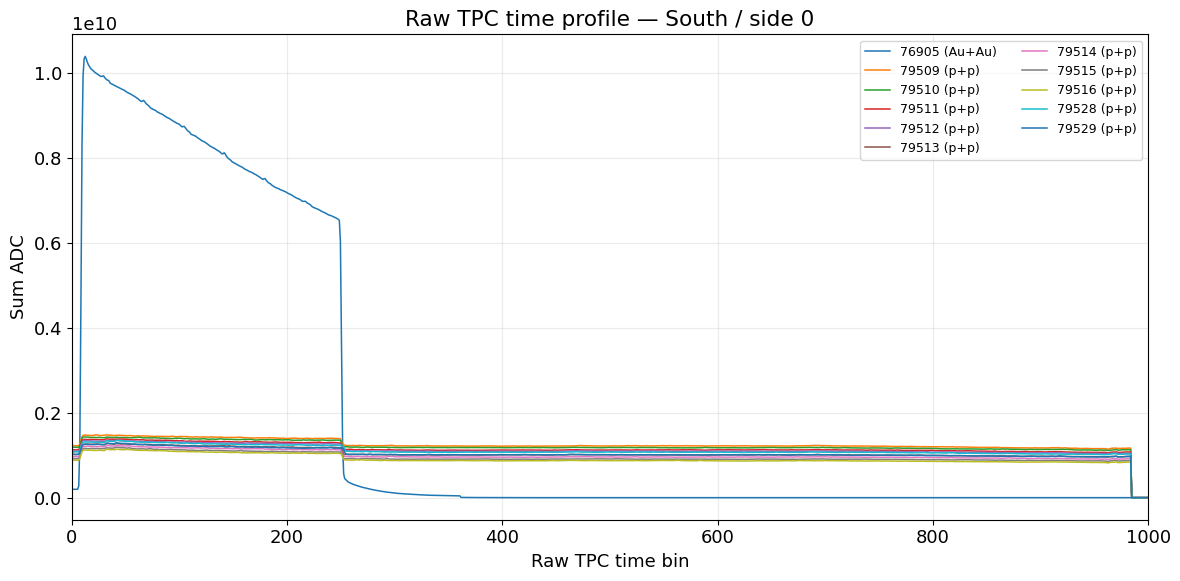

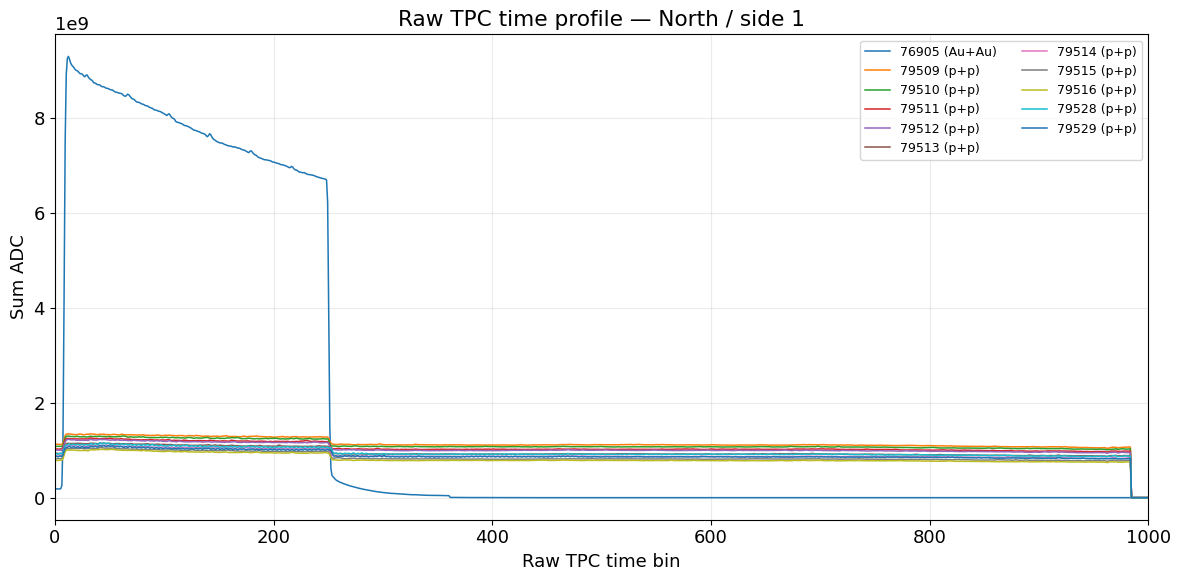

In [6]:

# ============================================================
# 1. Raw full time profiles
# ============================================================

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue
        x, y, _ = DATA[run]["time"][side]
        ax.plot(x, y, lw=1.1, label=f"{run} ({GROUP_OF_RUN[run]})")

    ax.set_xlim(*TIME_FULL_XLIM)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Sum ADC")
    ax.set_title(f"Raw TPC time profile — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_raw_side{side}.png", dpi=160)
        fig.savefig(OUTPUT_DIR / f"time_raw_side{side}.pdf")

    plt.show()


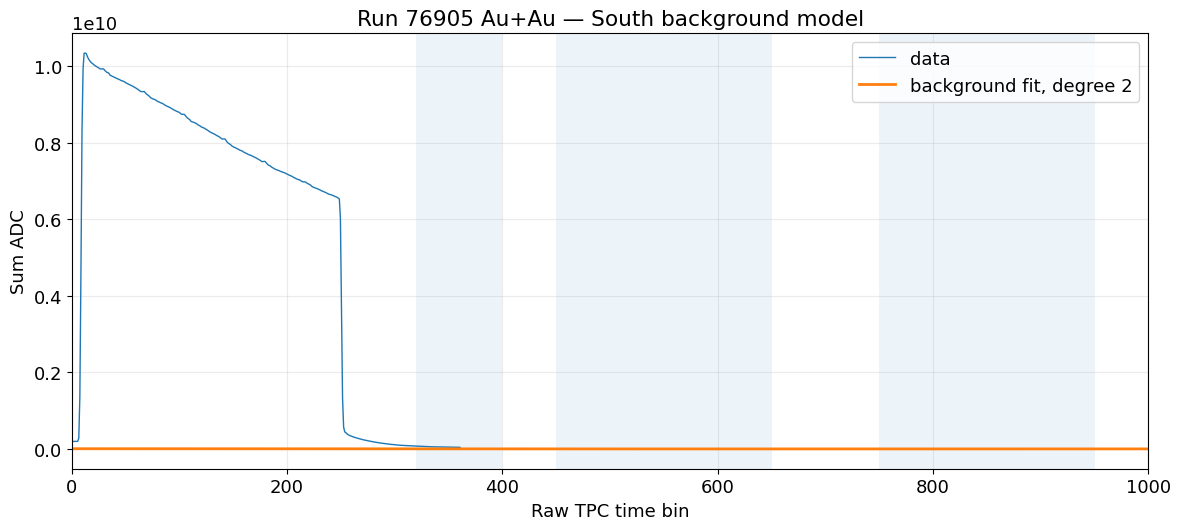

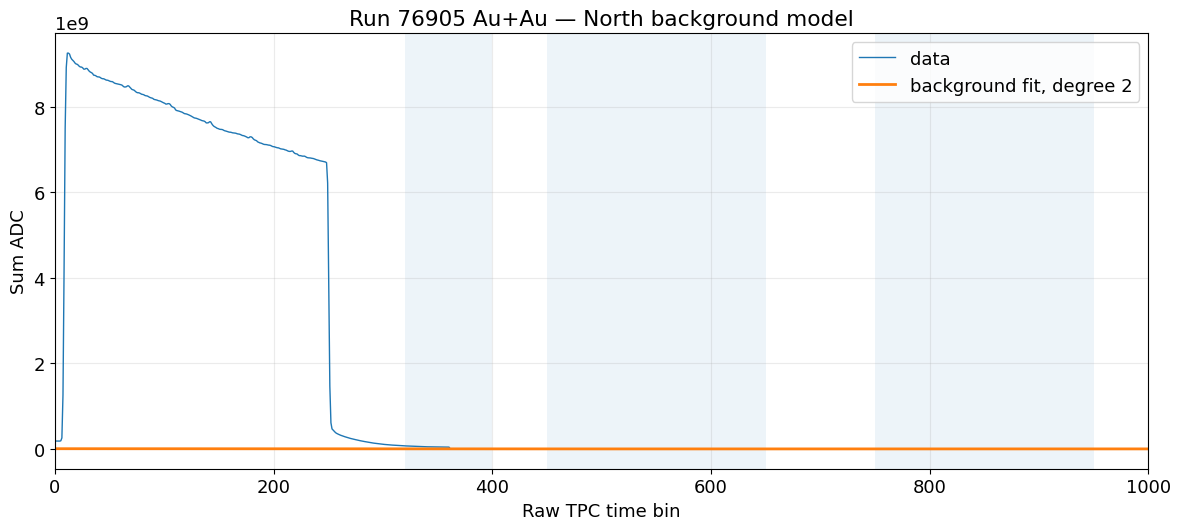

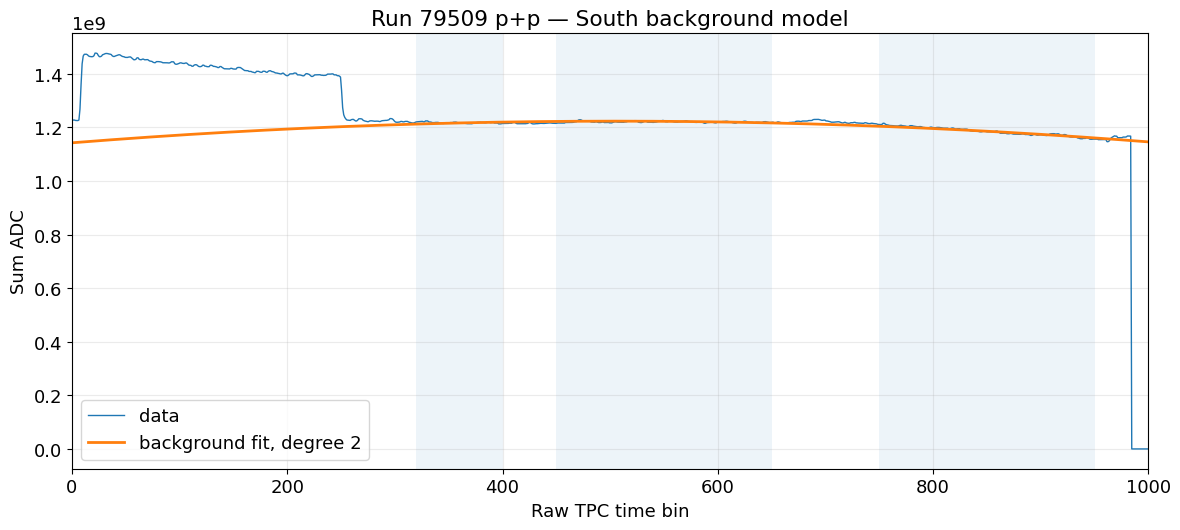

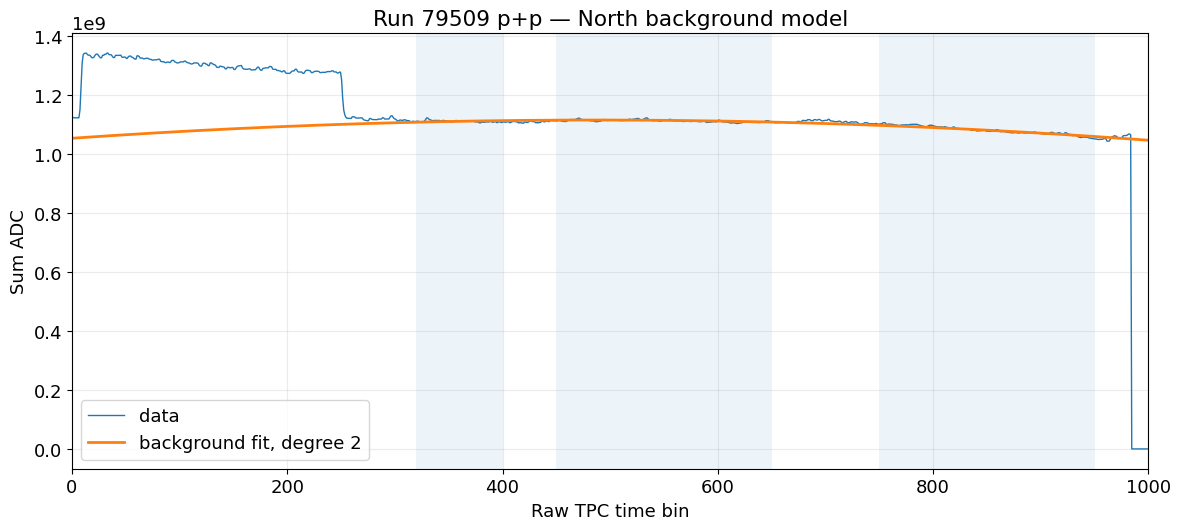

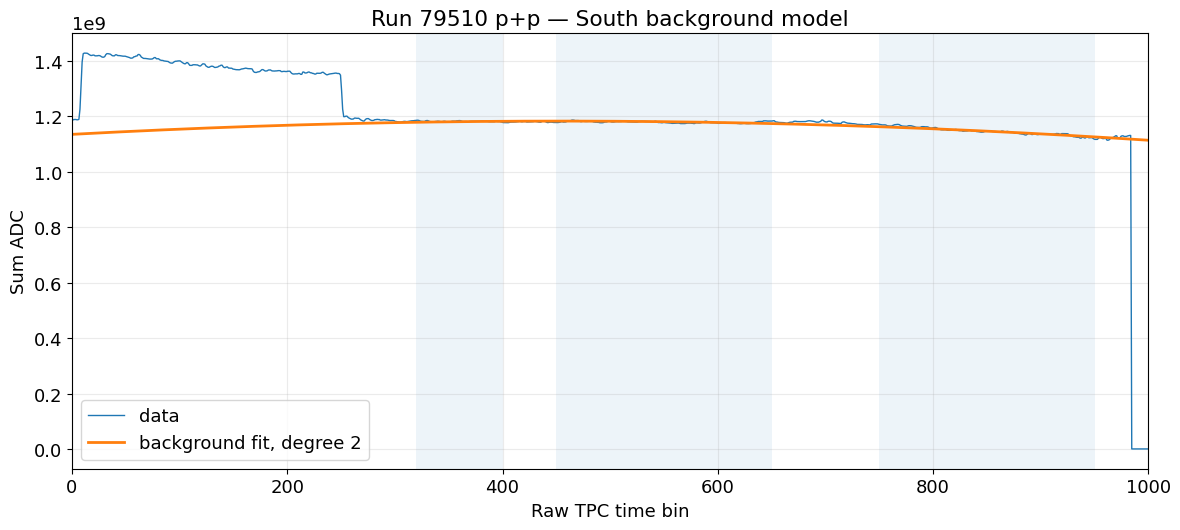

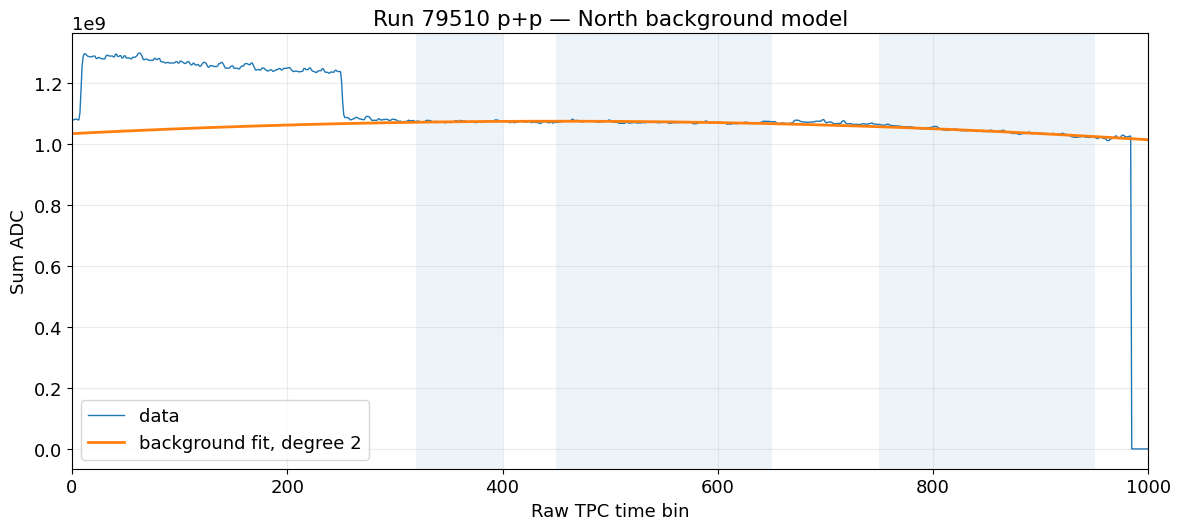

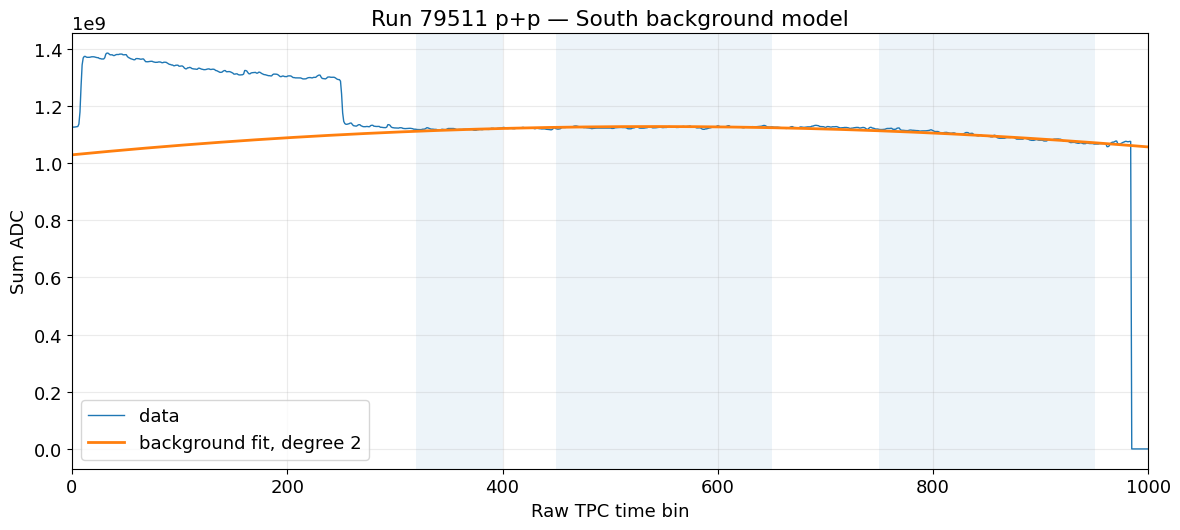

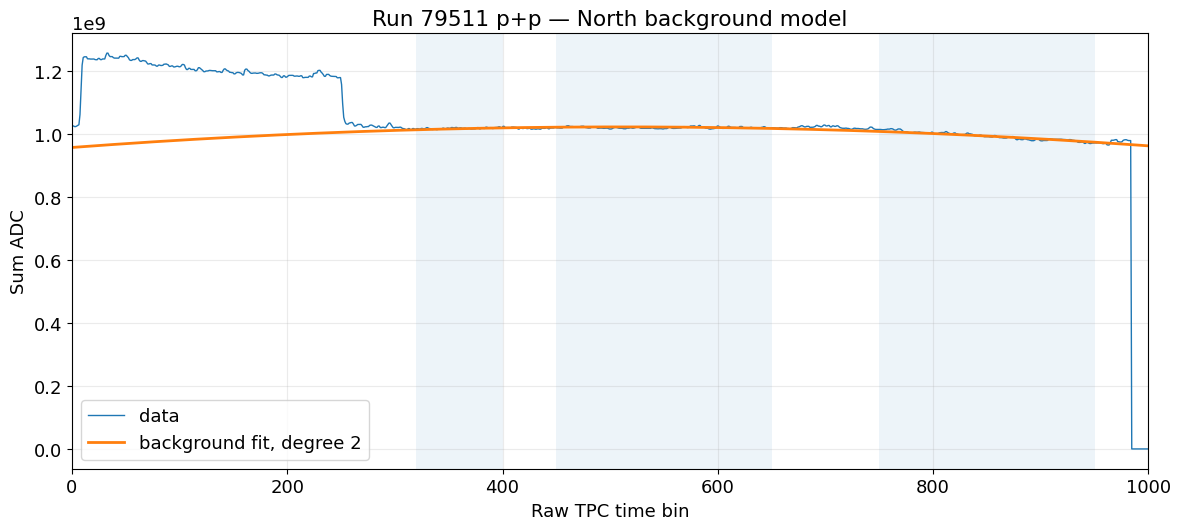

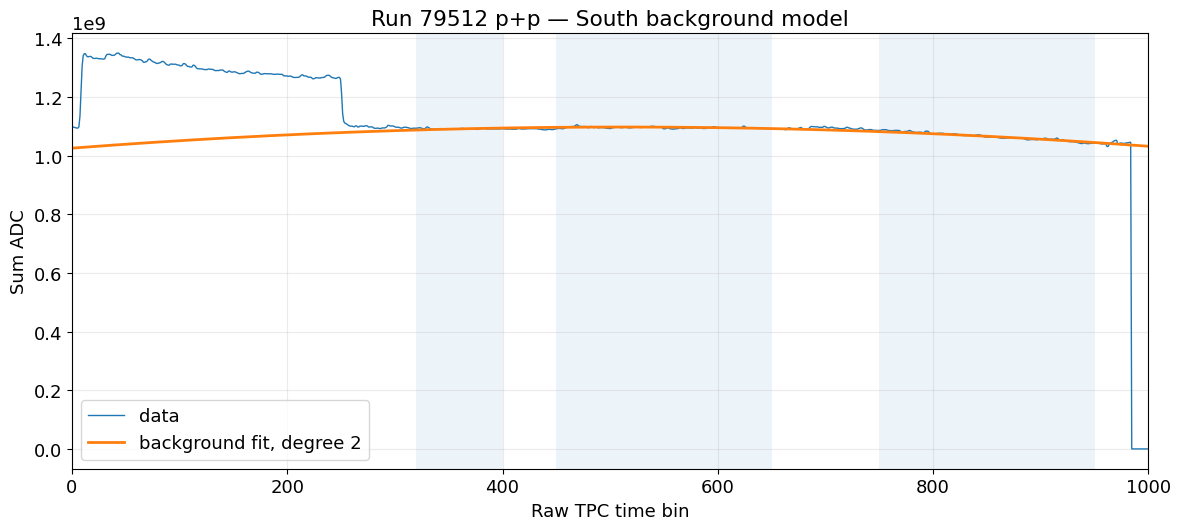

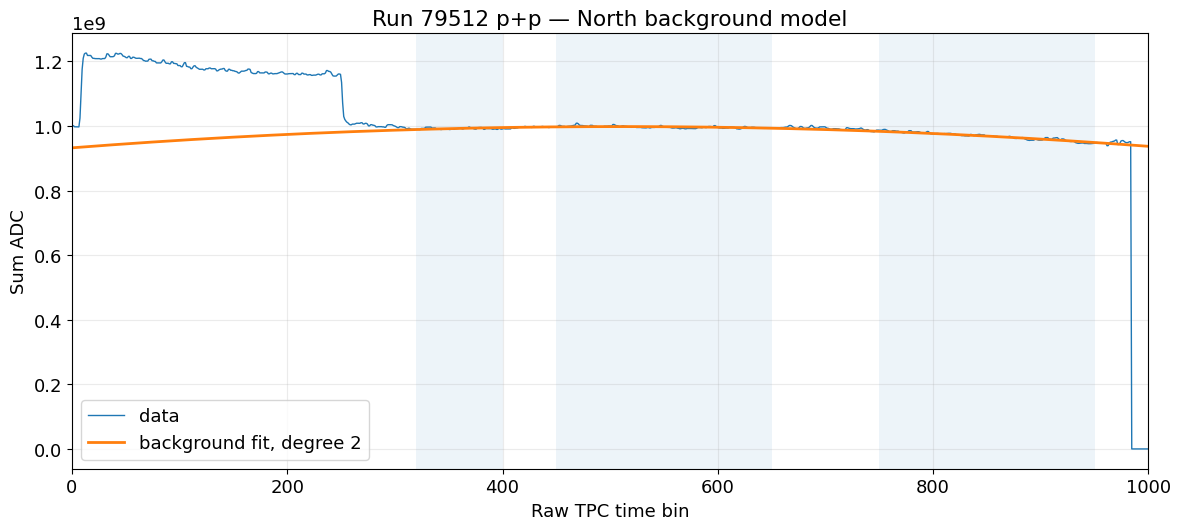

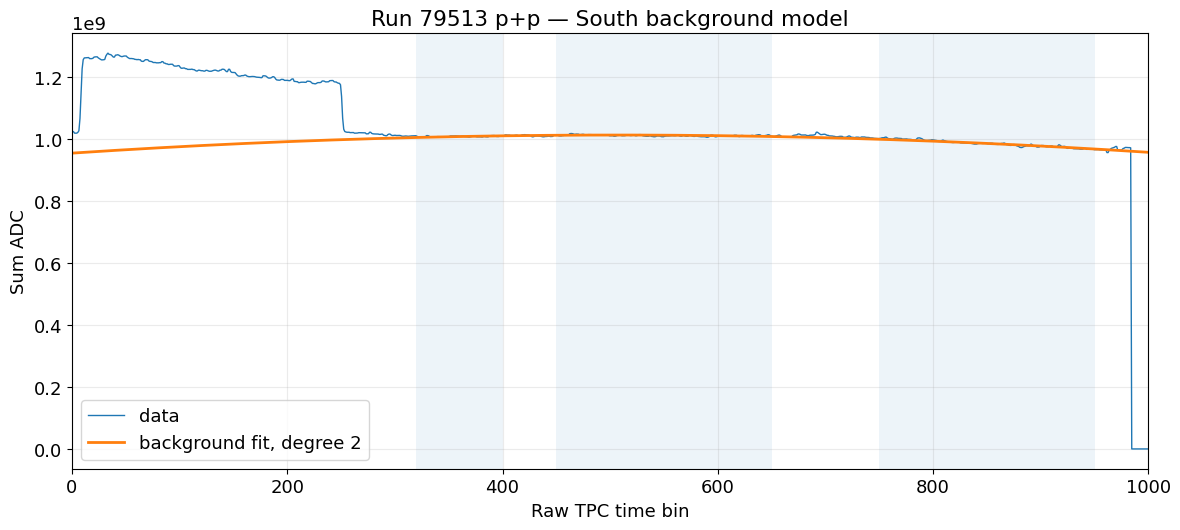

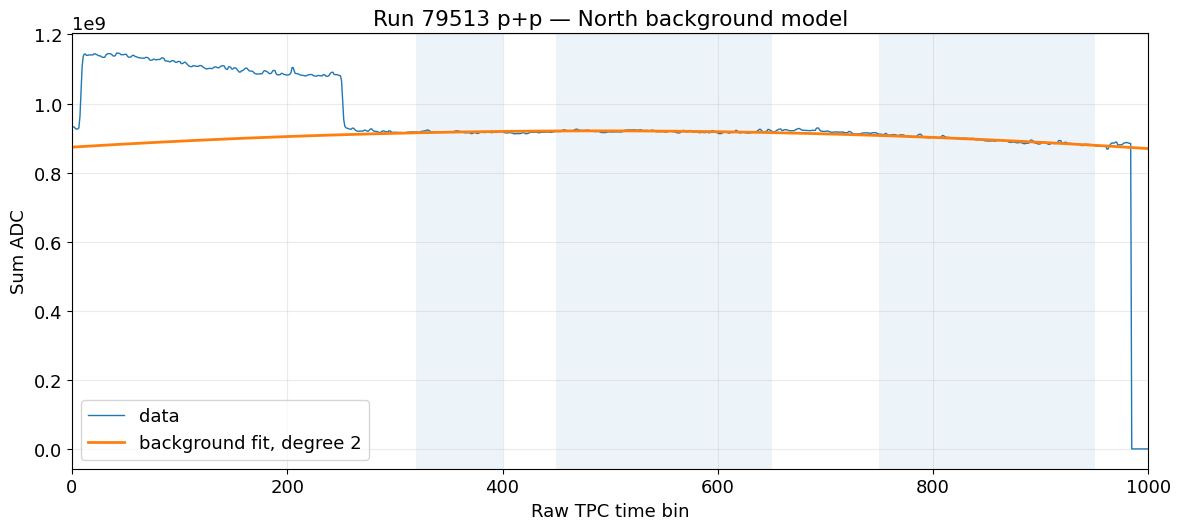

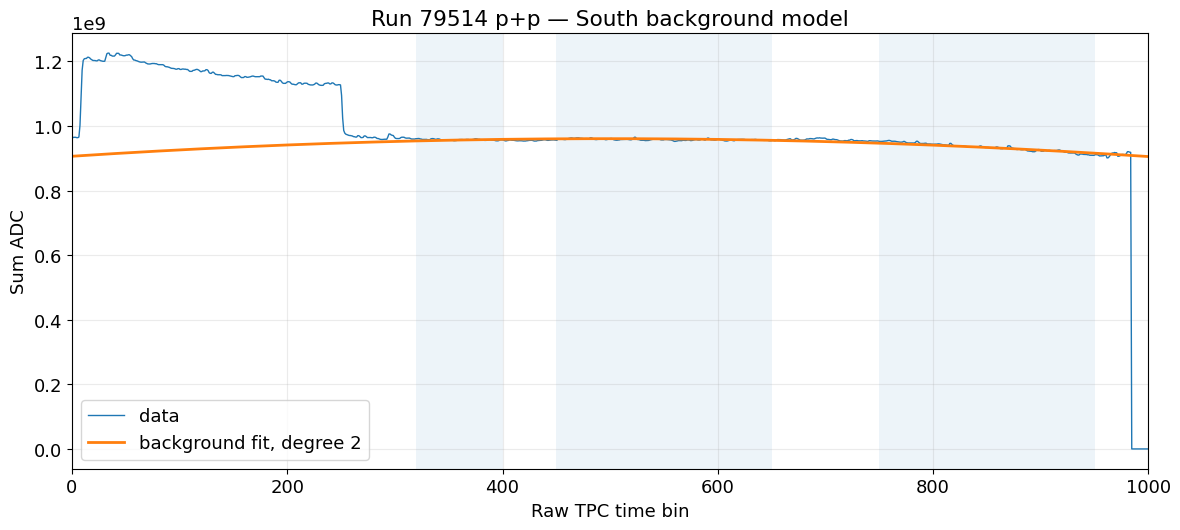

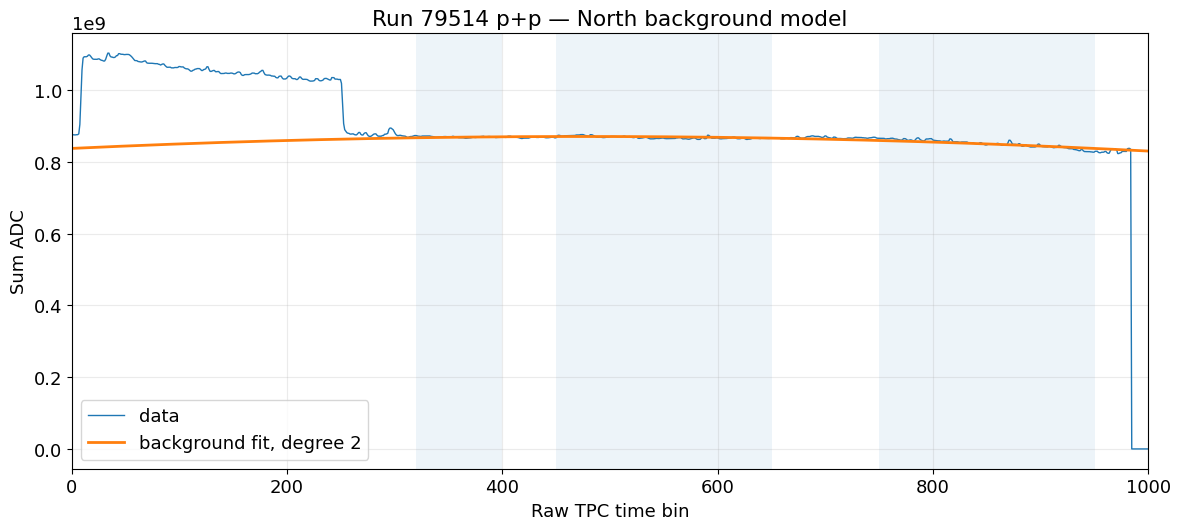

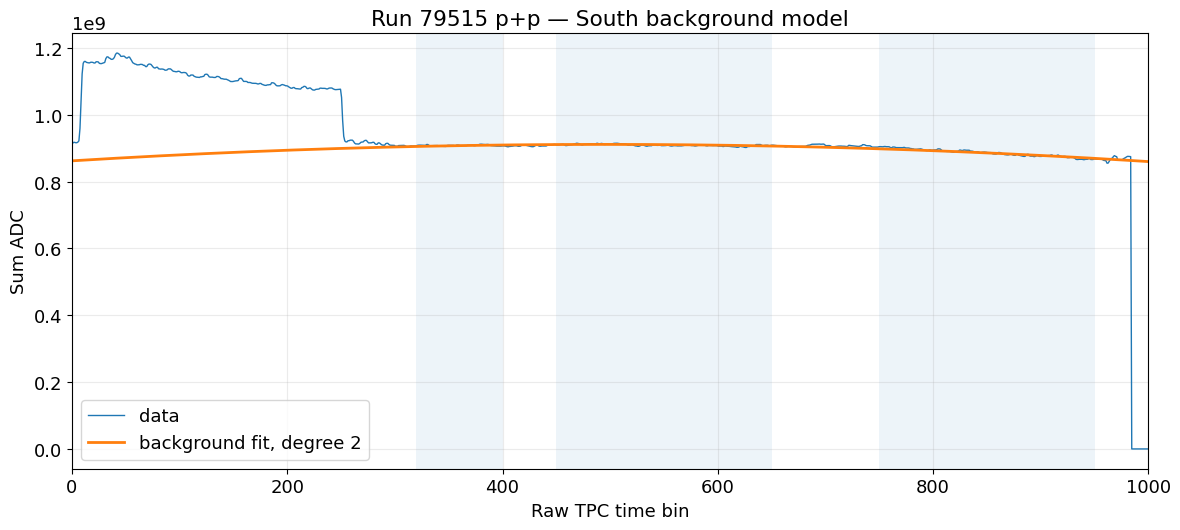

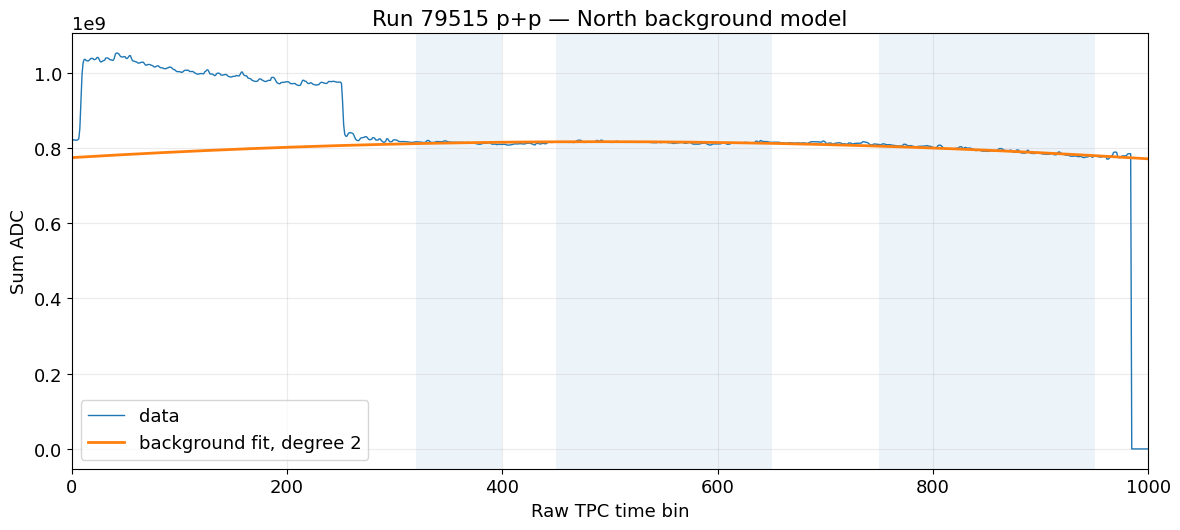

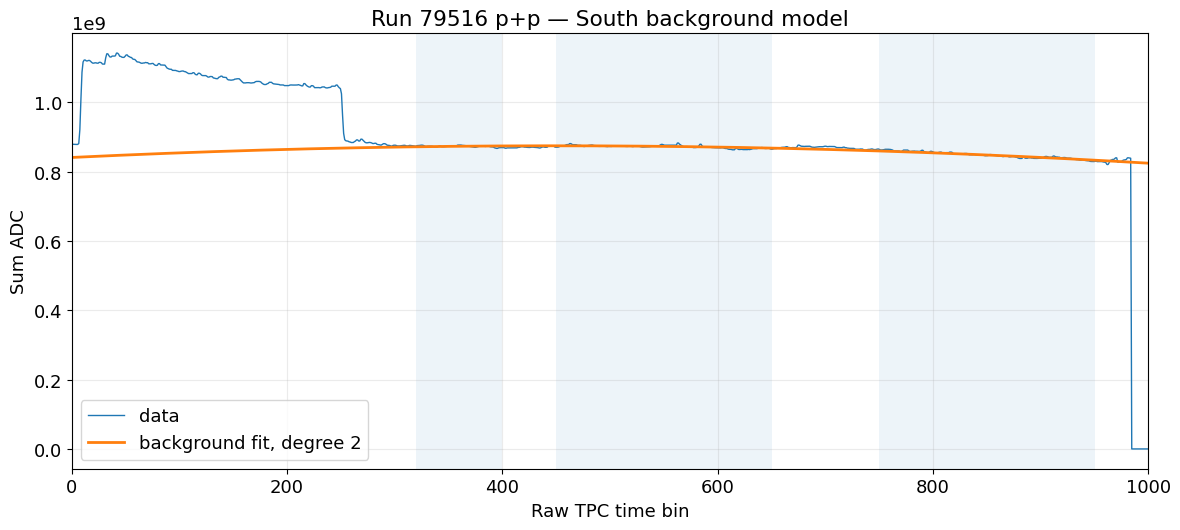

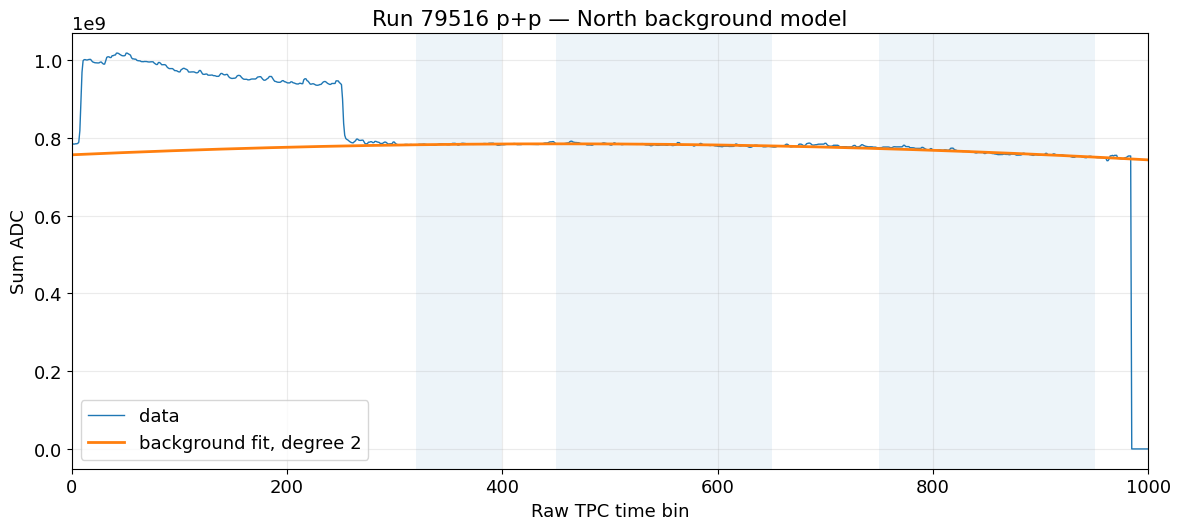

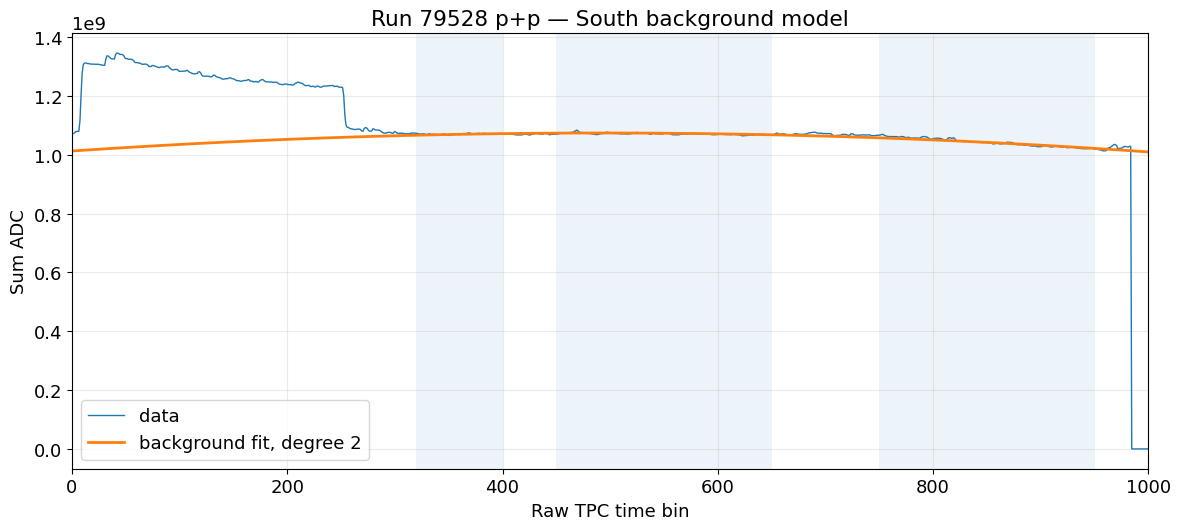

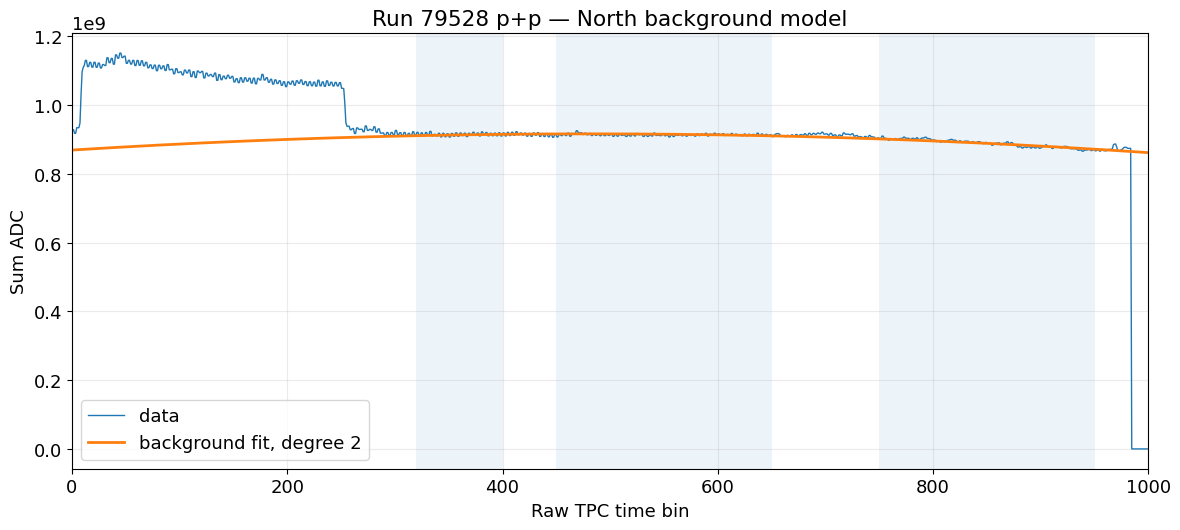

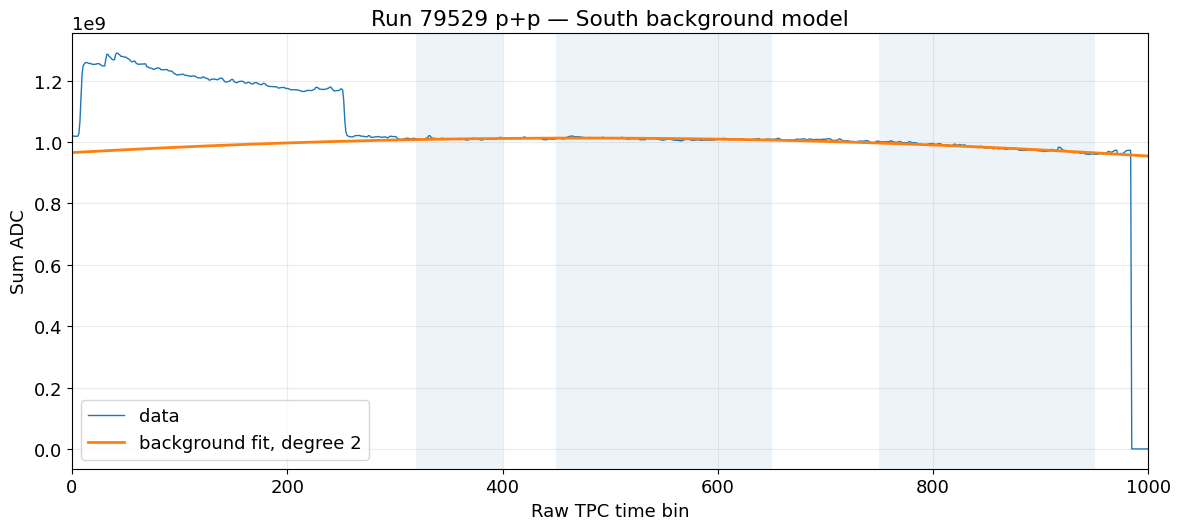

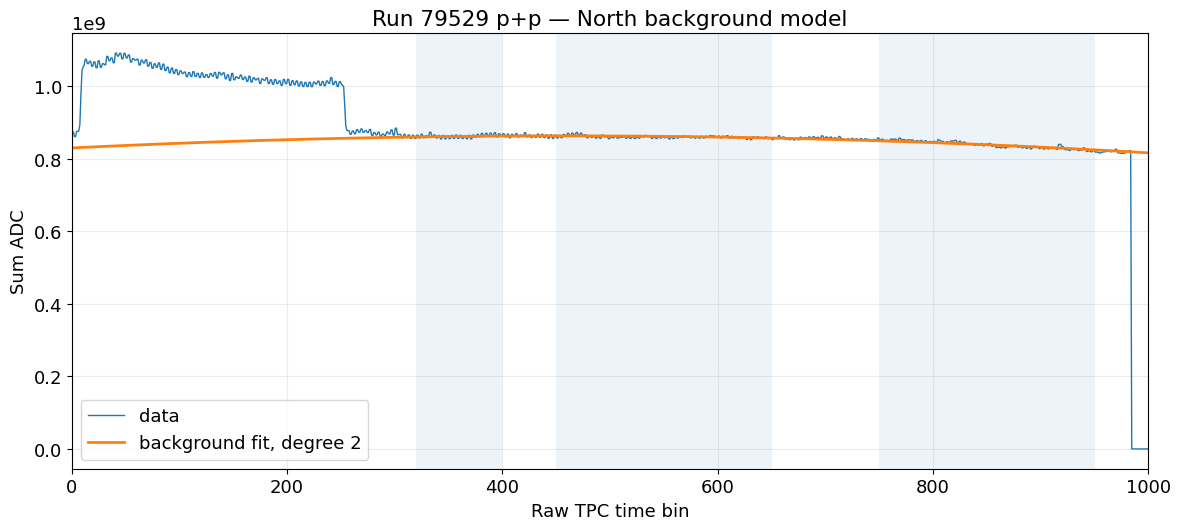

In [7]:

# ============================================================
# 2. Inspect background fit and pedestal subtraction run-by-run
# ============================================================

TIME_CORRECTED = {}

for run in AVAILABLE_RUNS:
    TIME_CORRECTED[run] = {}

    for side in (0, 1):
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]
        y_sub, bg, p, used = subtract_time_background(x, y)
        y_norm = normalize_drift_signal(x, y_sub)

        TIME_CORRECTED[run][side] = {
            "x": x,
            "raw": y,
            "clean": display_clean(y),
            "bg": bg,
            "sub": y_sub,
            "norm": y_norm,
            "poly": p,
        }

        fig, ax = plt.subplots(figsize=(12, 5.5))
        ax.plot(x, display_clean(y), lw=1.0, label="data")
        ax.plot(x, bg, lw=2.0, label=f"background fit, degree {TIME_BG_POLY_DEGREE}")

        for lo, hi in TIME_BG_WINDOWS:
            ax.axvspan(lo, hi, alpha=0.08)

        ax.set_xlim(*TIME_FULL_XLIM)
        ax.set_xlabel("Raw TPC time bin")
        ax.set_ylabel("Sum ADC")
        ax.set_title(f"Run {run} {GROUP_OF_RUN[run]} — {SIDE_LABEL[side]} background model")
        ax.legend()
        fig.tight_layout()

        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / f"time_background_run{run}_side{side}.png", dpi=150)

        plt.show()


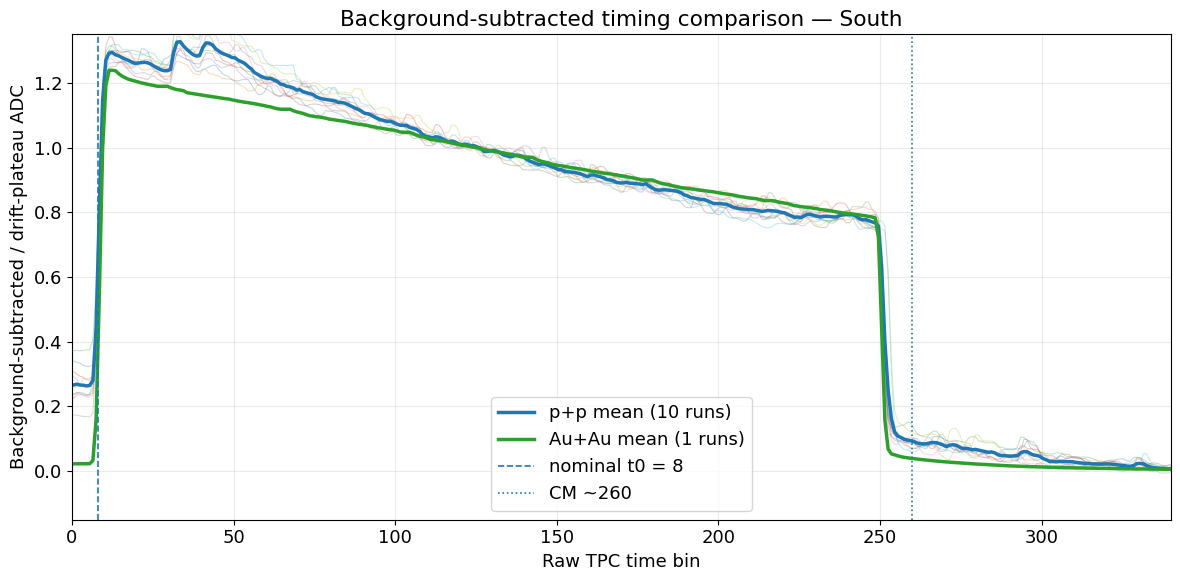

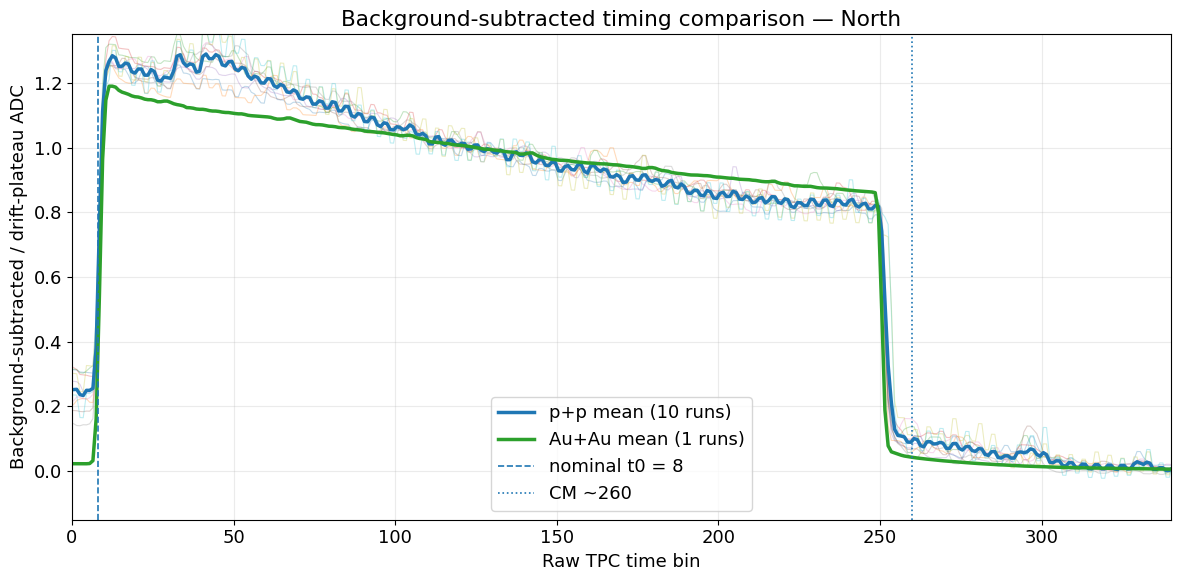

In [8]:

# ============================================================
# 3. p+p vs Au+Au after background subtraction
#    normalized to the active drift plateau
# ============================================================

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for group, runs in RUN_GROUPS.items():
        group_curves = []
        x_group = None

        for run in runs:
            if run not in TIME_CORRECTED or side not in TIME_CORRECTED[run]:
                continue

            d = TIME_CORRECTED[run][side]
            x = d["x"]
            y = d["norm"]
            x_group = x
            group_curves.append(y)

            ax.plot(x, y, lw=0.8, alpha=0.28)

        if group_curves:
            mean = np.nanmean(np.vstack(group_curves), axis=0)
            ax.plot(x_group, mean, lw=2.5, label=f"{group} mean ({len(group_curves)} runs)")

    ax.axvline(T0_EXPECTED, ls="--", lw=1.2, label="nominal t0 = 8")
    ax.axvline(CM_EXPECTED, ls=":", lw=1.2, label="CM ~260")
    ax.set_xlim(0, 340)
    ax.set_ylim(-0.15, 1.35)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Background-subtracted / drift-plateau ADC")
    ax.set_title(f"Background-subtracted timing comparison — {SIDE_LABEL[side]}")
    ax.legend()
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_subtracted_compare_side{side}.png", dpi=160)
        fig.savefig(OUTPUT_DIR / f"time_subtracted_compare_side{side}.pdf")

    plt.show()



## \(t_0\) edge near the pad plane

For this plot the normalization is **local**:

- level before the edge: `T0_LEFT_LEVEL`;
- plateau after the edge: `T0_RIGHT_LEVEL`.

The 50% crossing is used as the run-by-run \(t_0\) estimator.  
The 10–90% width is retained as a QA quantity for edge broadening/noise.


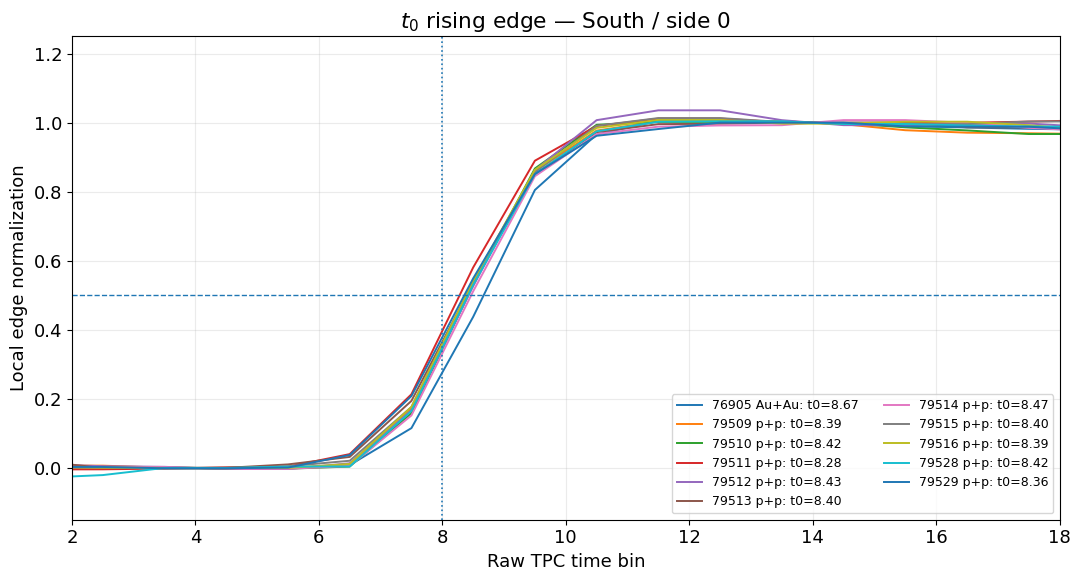

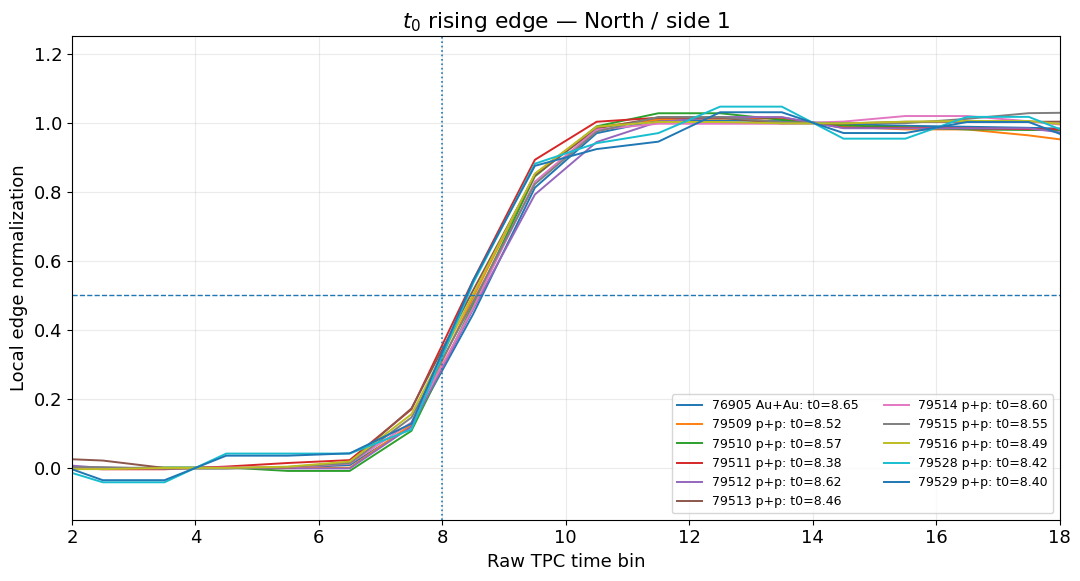

In [9]:

# ============================================================
# 4. t0 edge: local normalized comparison
# ============================================================

T0_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]
        m = edge_metrics(
            x, y,
            T0_LEFT_LEVEL,
            T0_RIGHT_LEVEL,
            T0_SEARCH,
            expected=T0_EXPECTED,
        )

        T0_RESULTS[(run, side)] = m
        yn = normalize_between_levels(display_clean(y), m["left_level"], m["right_level"])

        ax.plot(x, yn, lw=1.4, label=f"{run} {GROUP_OF_RUN[run]}: t0={m['x50']:.2f}")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(T0_EXPECTED, ls=":", lw=1.2)
    ax.set_xlim(*T0_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"$t_0$ rising edge — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"t0_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"t0_zoom_side{side}.pdf")

    plt.show()



## Central-membrane edge and data drift velocity

The central-membrane falling edge is extracted independently of the \(t_0\) edge.

\[
\Delta t_{\rm drift}
=
(t_{\rm CM}-t_0)\times 56.8~{\rm ns},
\]

\[
v_{\rm drift}^{\rm data}
=
\frac{102.605~{\rm cm}}{\Delta t_{\rm drift}}.
\]

The summary table reports the velocity in cm/\(\mu\)s.


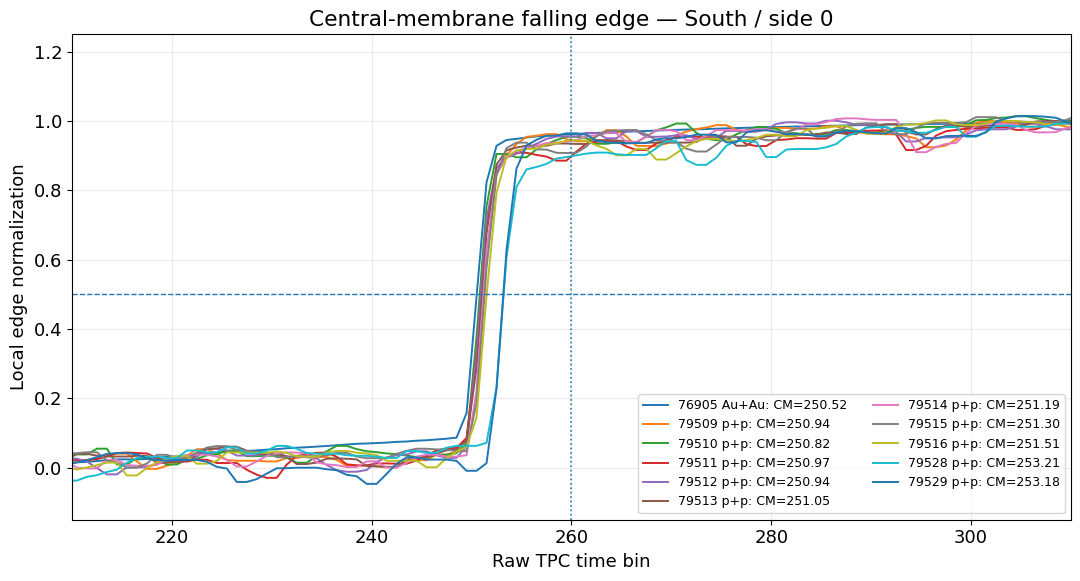

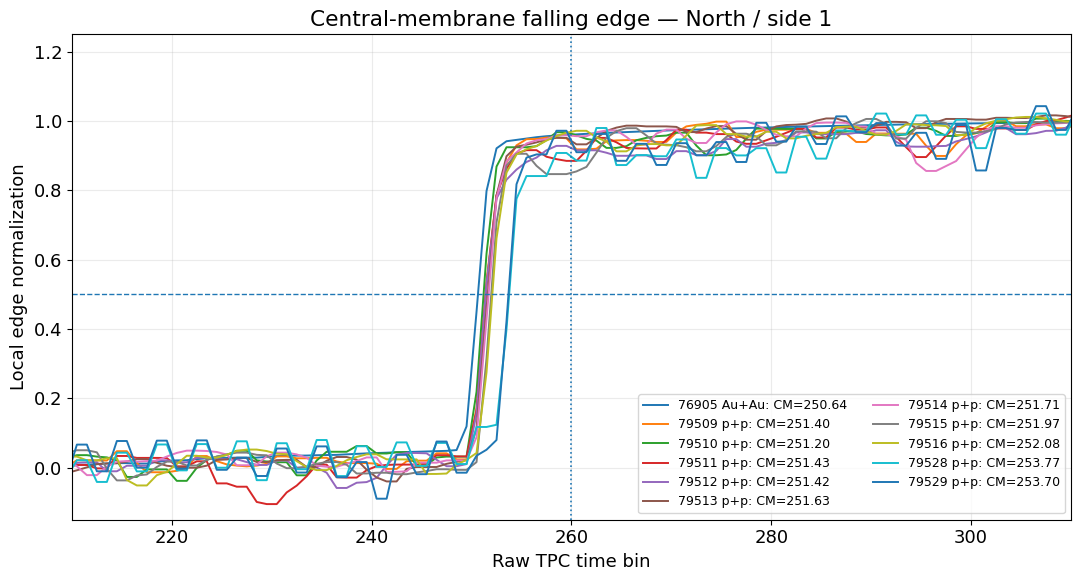

In [10]:

# ============================================================
# 5. CM falling edge
# ============================================================

CM_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]
        m = edge_metrics(
            x, y,
            CM_LEFT_LEVEL,
            CM_RIGHT_LEVEL,
            CM_SEARCH,
            expected=CM_EXPECTED,
        )

        CM_RESULTS[(run, side)] = m
        yn = normalize_between_levels(display_clean(y), m["left_level"], m["right_level"])

        ax.plot(x, yn, lw=1.4, label=f"{run} {GROUP_OF_RUN[run]}: CM={m['x50']:.2f}")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(CM_EXPECTED, ls=":", lw=1.2)
    ax.set_xlim(*CM_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"Central-membrane falling edge — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"cm_time_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"cm_time_zoom_side{side}.pdf")

    plt.show()


In [11]:

# ============================================================
# 6. Run-by-run t0 / CM / drift-velocity summary
# ============================================================

rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):
        t0 = T0_RESULTS.get((run, side))
        cm = CM_RESULTS.get((run, side))
        if t0 is None or cm is None:
            continue

        t0_bin = t0["x50"]
        cm_bin = cm["x50"]
        dt_bins = cm_bin - t0_bin
        dt_ns = dt_bins * TPC_TIME_BIN_NS

        v_cm_us = np.nan
        if np.isfinite(dt_ns) and dt_ns > 0:
            v_cm_us = Z_PAD_CM / dt_ns * 1000.0

        rows.append({
            "run": run,
            "system": GROUP_OF_RUN[run],
            "side": side,
            "side_name": SIDE_LABEL[side],
            "t0_bin_50": t0_bin,
            "t0_width_10_90_bins": t0["width_10_90"],
            "cm_bin_50": cm_bin,
            "cm_width_10_90_bins": cm["width_10_90"],
            "drift_bins": dt_bins,
            "drift_time_ns": dt_ns,
            "vdrift_data_cm_us": v_cm_us,
        })

SUMMARY = pd.DataFrame(rows).sort_values(["run", "side"]).reset_index(drop=True)
display(SUMMARY)

SUMMARY.to_csv(OUTPUT_DIR / "drift_t0_summary.csv", index=False)
print("saved:", OUTPUT_DIR / "drift_t0_summary.csv")


,run,system,side,side_name,t0_bin_50,t0_width_10_90_bins,cm_bin_50,cm_width_10_90_bins,drift_bins,drift_time_ns,vdrift_data_cm_us
0,76905,Au+Au,0,South,8.670098,2.733876,250.520815,3.543550,241.850717,13737.120734,7.469178
1,76905,Au+Au,1,North,8.648595,2.734163,250.643224,3.108366,241.994629,13745.294916,7.464736
2,79509,p+p,0,South,8.389627,2.785865,250.942977,3.852117,242.553350,13777.030284,7.447541
3,79509,p+p,1,North,8.517120,2.561883,251.395358,3.881336,242.878238,13795.483944,7.437579
4,79510,p+p,0,South,8.418637,2.636628,250.824619,6.107344,242.405982,13768.659797,7.452069
5,79510,p+p,1,North,8.572814,2.447461,251.204808,3.200840,242.631994,13781.497258,7.445127
6,79511,p+p,0,South,8.280657,2.755373,250.971720,10.485294,242.691063,13784.852376,7.443315
7,79511,p+p,1,North,8.384021,2.542517,251.429425,10.996634,243.045404,13804.978921,7.432463
8,79512,p+p,0,South,8.426613,2.696697,250.935686,4.253930,242.509072,13774.515307,7.448901
9,79512,p+p,1,North,8.620433,2.874914,251.417493,6.650210,242.797060,13790.873010,7.440066


saved: plots_drift_t0/drift_t0_summary.csv


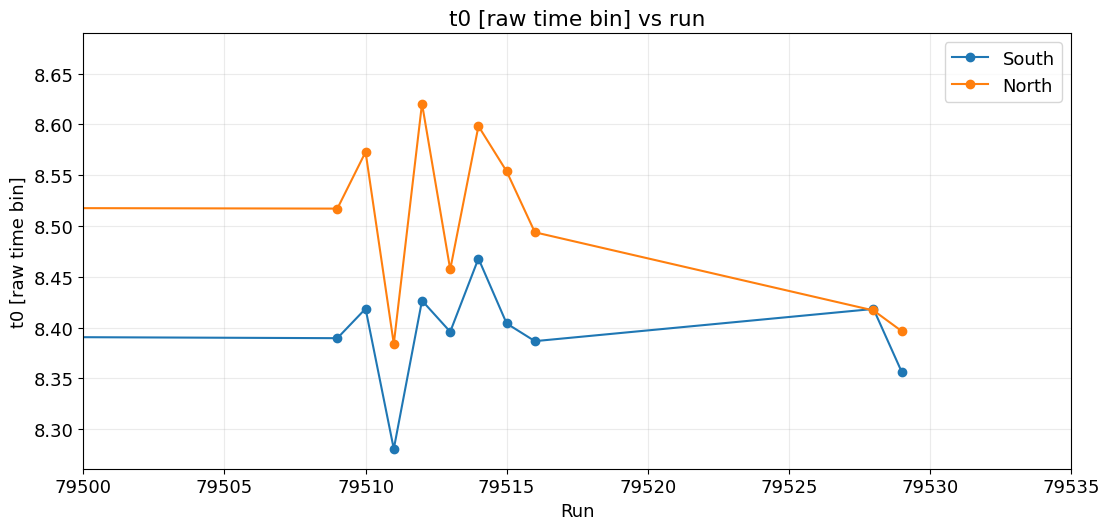

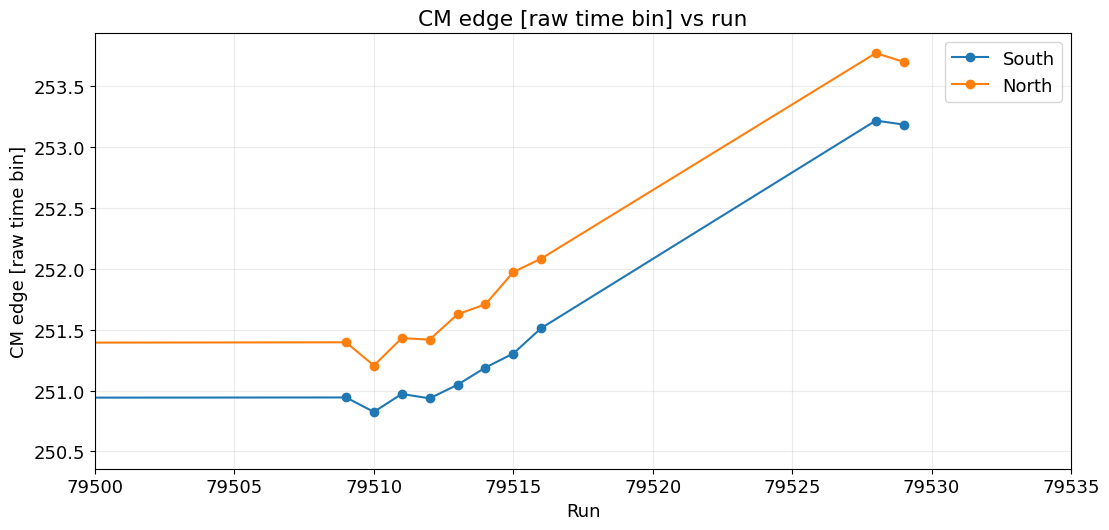

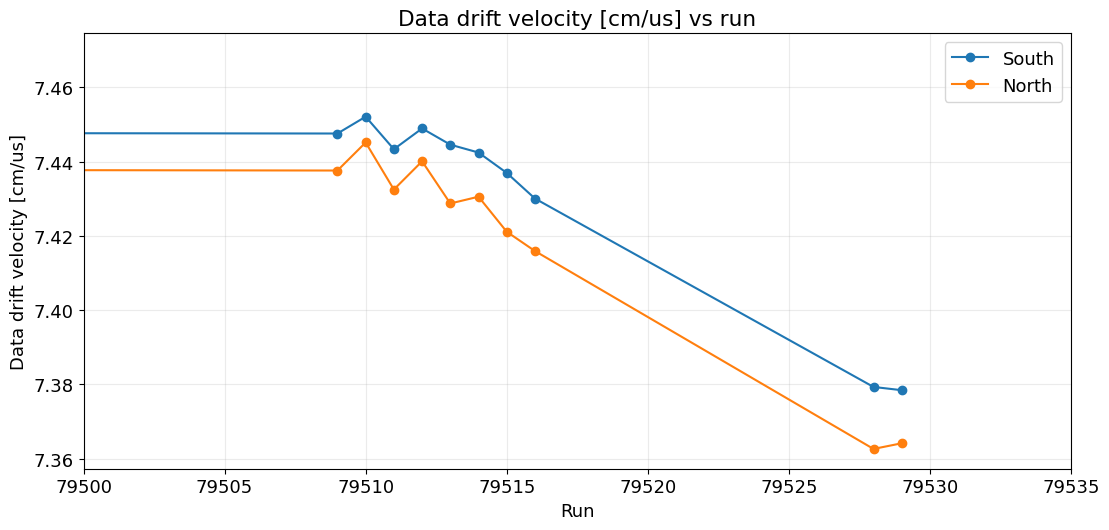

In [24]:

# ============================================================
# 7. Run-by-run extracted t0, CM time, and drift velocity
# ============================================================

if len(SUMMARY):
    for quantity, ylabel, fname in [
        ("t0_bin_50", "t0 [raw time bin]", "summary_t0"),
        ("cm_bin_50", "CM edge [raw time bin]", "summary_cm"),
        ("vdrift_data_cm_us", "Data drift velocity [cm/us]", "summary_vdrift"),
    ]:
        fig, ax = plt.subplots(figsize=(11, 5.5))

        for side in (0, 1):
            ss = SUMMARY[SUMMARY["side"] == side]
            ax.plot(ss["run"], ss[quantity], "o-", label=SIDE_LABEL[side])

        ax.set_xlabel("Run")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel + " vs run")
        ax.legend()
        fig.tight_layout()
        ax.set_xlim(79500, 79535)

        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / f"{fname}.png", dpi=170)
            fig.savefig(OUTPUT_DIR / f"{fname}.pdf")

        plt.show()



## PHGarfield-\(z\) comparison

For comparing North and South directly, define the **side-folded coordinate**

\[
u =
\begin{cases}
-z, & \text{South},\\
+z, & \text{North}.
\end{cases}
\]

Then the nominal active half-TPC is approximately

\[
0 < u < 102.605~{\rm cm}.
\]

Checks:

- **CM edge:** should be near \(u=0\). A displacement is a residual between the PHGarfield \(P/T\)-corrected mapping and the data.
- **Pad-plane / \(t_0\) edge:** should be near \(u\simeq102.605\) cm.


### Important z-binning point

The original QA histogram uses 1000 bins over \(-130<z<130\) cm, i.e. \(0.26\) cm/bin.  
But one raw TPC time bin corresponds to roughly \(0.4\) cm in drift distance. Therefore the direct
`time bin -> z bin` fill cannot populate every z bin and produces the large comb-like fluctuations seen
in the raw plot. These are **not physical fluctuations**.

For all z plots below the notebook first **integrates 4 neighboring z bins**, giving an effective
bin width of about \(1.04\) cm. This is done before background subtraction, normalization, or edge finding.
No Fun4All rerun is needed.


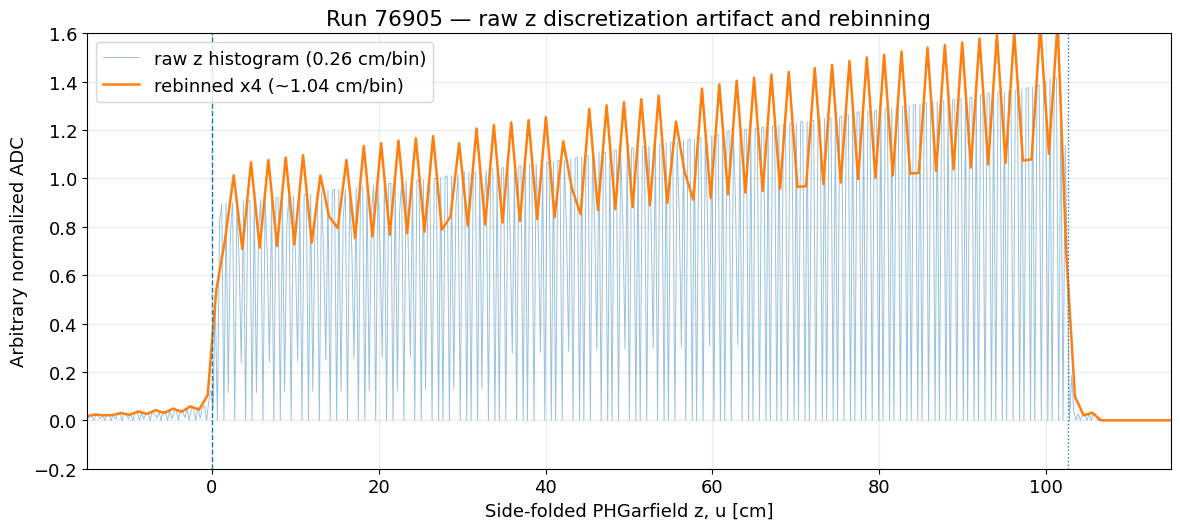

In [13]:
# ============================================================
# z binning diagnostic: raw comb structure vs rebinned profile
# ============================================================

Z_DIAGNOSTIC_RUN = AVAILABLE_RUNS[0]
Z_DIAGNOSTIC_SIDE = 0

if Z_DIAGNOSTIC_SIDE in DATA[Z_DIAGNOSTIC_RUN]["z"]:
    z_raw, y_raw, _ = DATA[Z_DIAGNOSTIC_RUN]["z"][Z_DIAGNOSTIC_SIDE]

    sign = +1.0 if Z_DIAGNOSTIC_SIDE == 1 else -1.0
    u_raw = sign * z_raw
    order = np.argsort(u_raw)
    u_raw = u_raw[order]
    y_raw = y_raw[order]

    u_reb, y_reb = rebin_1d_sum(u_raw, y_raw, Z_REBIN_FACTOR)

    # Shape comparison only.
    raw_scale = np.nanmedian(y_raw[(u_raw > 20) & (u_raw < 80)])
    reb_scale = np.nanmedian(y_reb[(u_reb > 20) & (u_reb < 80)])

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.plot(u_raw, y_raw / raw_scale, lw=0.7, alpha=0.45,
            label="raw z histogram (0.26 cm/bin)")
    ax.plot(u_reb, y_reb / reb_scale, lw=1.8,
            label=f"rebinned x{Z_REBIN_FACTOR} (~{0.26*Z_REBIN_FACTOR:.2f} cm/bin)")

    ax.axvline(0, ls="--", lw=1)
    ax.axvline(Z_PAD_CM, ls=":", lw=1)
    ax.set_xlim(-15, 115)
    ax.set_ylim(-0.2, 1.6)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Arbitrary normalized ADC")
    ax.set_title(
        f"Run {Z_DIAGNOSTIC_RUN} — raw z discretization artifact and rebinning"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()


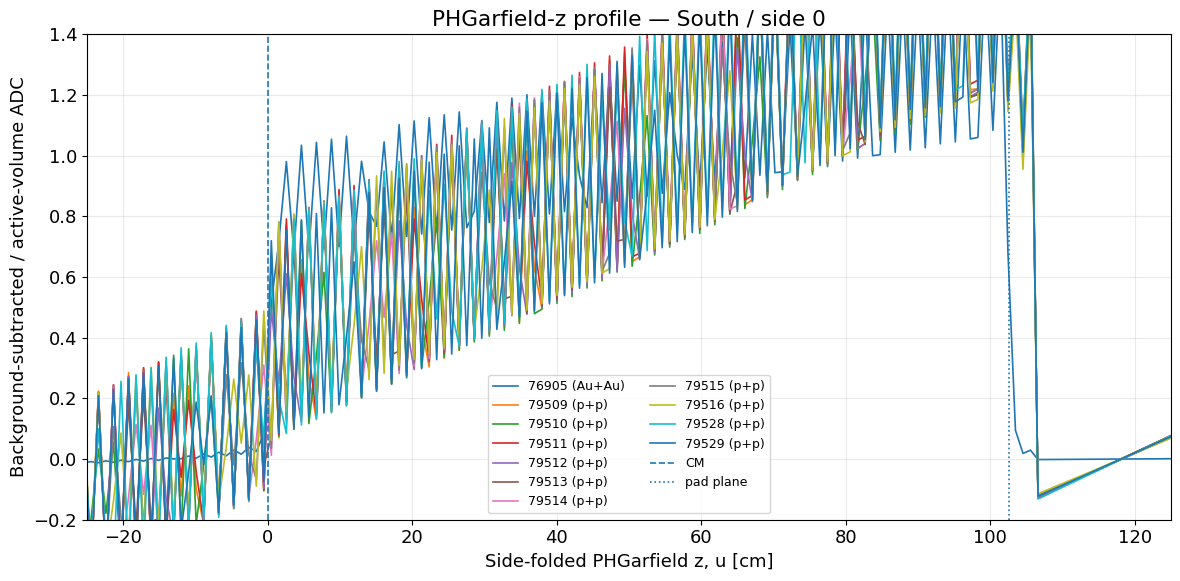

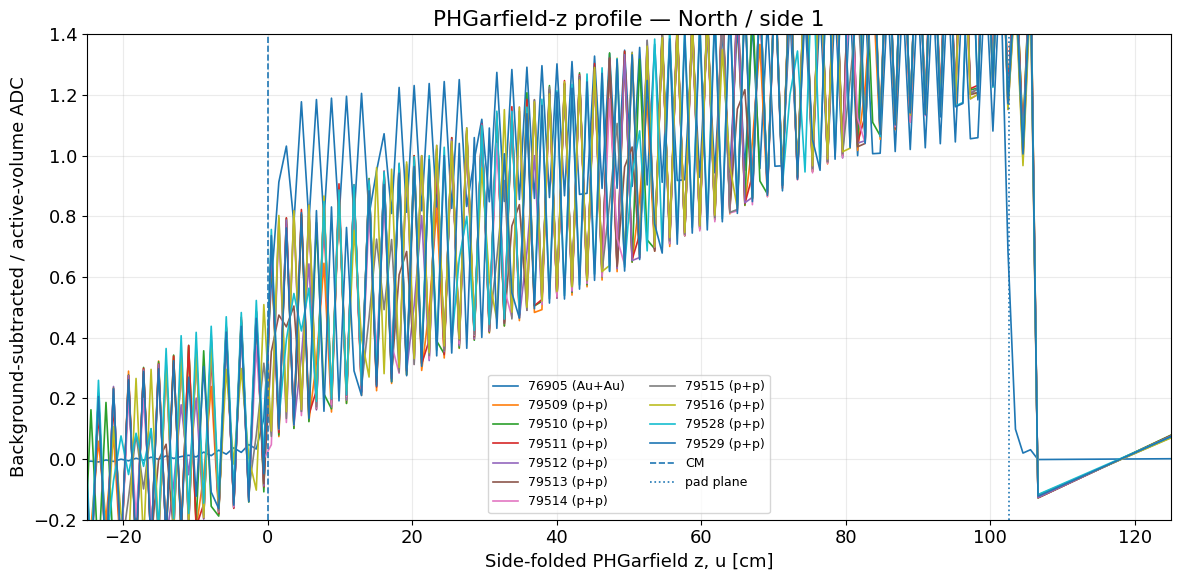

In [14]:

# ============================================================
# 8. Folded-z full profiles
# ============================================================

Z_FOLDED = {}

for run in AVAILABLE_RUNS:
    Z_FOLDED[run] = {}

    for side in (0, 1):
        if side not in DATA[run]["z"]:
            continue

        z, y, _ = DATA[run]["z"][side]
        u, yy = fold_z(side, z, y)

        # Do not median-filter the raw 0.26-cm z bins.
        # The physically motivated x4 integration above removes the comb artifact
        # without smearing the CM and pad-plane edges unnecessarily.

        bg, p, used = robust_poly_background(
            u, yy, Z_BG_WINDOWS, degree=Z_BG_POLY_DEGREE
        )
        sub = yy - bg

        norm_level = window_median(u, sub, (20, 85))
        norm = sub / norm_level if np.isfinite(norm_level) and norm_level != 0 else np.full_like(sub, np.nan)

        Z_FOLDED[run][side] = {
            "u": u,
            "raw": yy,
            "bg": bg,
            "sub": sub,
            "norm": norm,
        }

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue
        d = Z_FOLDED[run][side]
        ax.plot(d["u"], d["norm"], lw=1.2, label=f"{run} ({GROUP_OF_RUN[run]})")

    ax.axvline(0, ls="--", lw=1.2, label="CM")
    ax.axvline(Z_PAD_CM, ls=":", lw=1.2, label="pad plane")
    ax.set_xlim(*Z_FULL_XLIM)
    ax.set_ylim(-0.2, 1.4)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Background-subtracted / active-volume ADC")
    ax.set_title(f"PHGarfield-z profile — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_folded_full_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_folded_full_side{side}.pdf")

    plt.show()


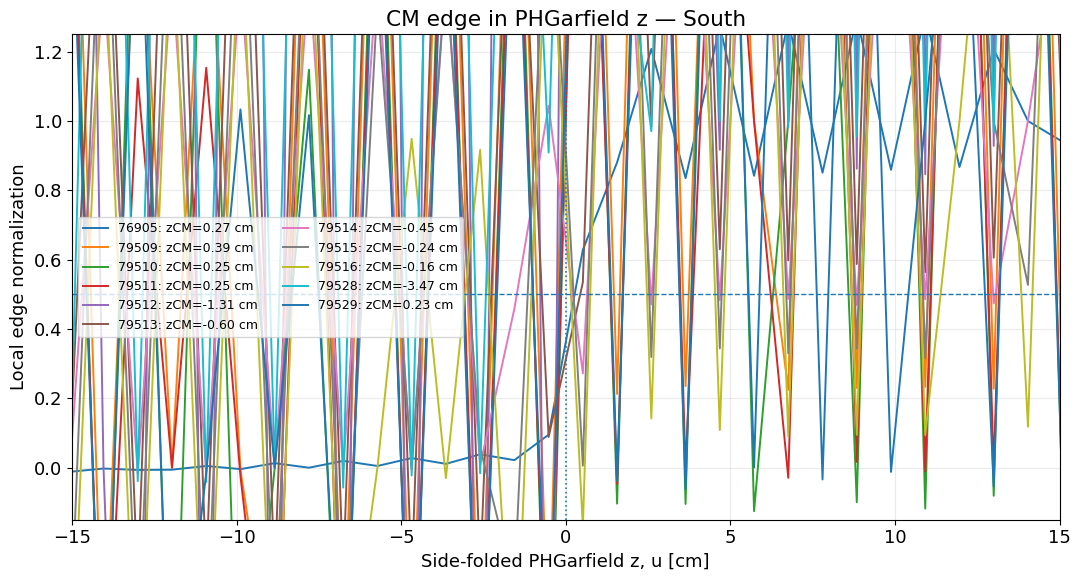

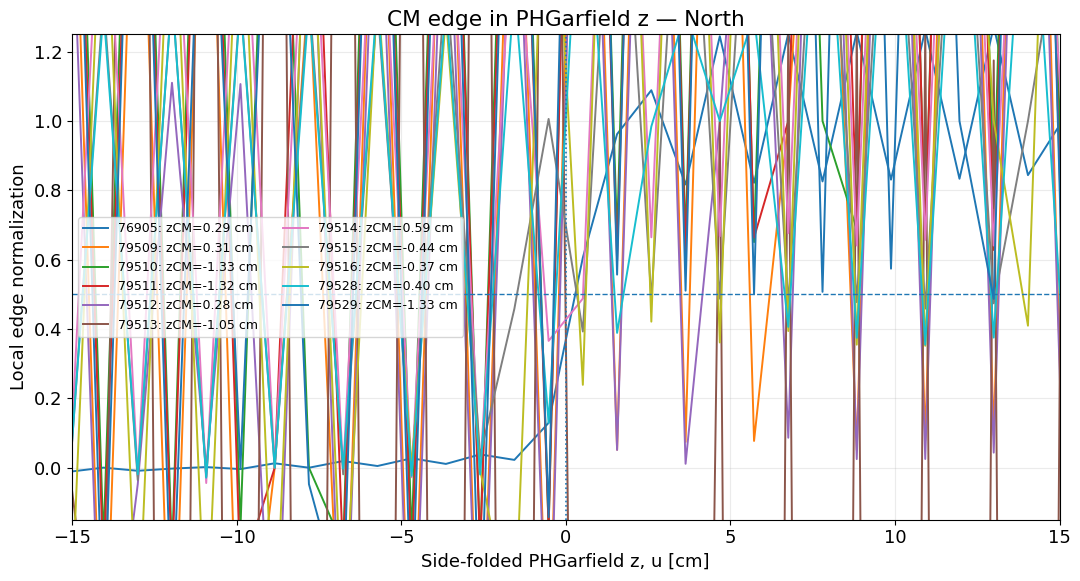

In [15]:

# ============================================================
# 9. PHGarfield-z CM edge near zero
# ============================================================

Z_CM_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue

        d = Z_FOLDED[run][side]
        u = d["u"]
        y = d["raw"]

        m = edge_metrics(
            u, y,
            Z_CM_LEFT_LEVEL,
            Z_CM_RIGHT_LEVEL,
            Z_CM_SEARCH,
            expected=Z_CM_EXPECTED,
        )
        Z_CM_RESULTS[(run, side)] = m

        yn = normalize_between_levels(y, m["left_level"], m["right_level"])
        ax.plot(u, yn, lw=1.4, label=f"{run}: zCM={m['x50']:.2f} cm")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(0, ls=":", lw=1.2)
    ax.set_xlim(*Z_CM_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"CM edge in PHGarfield z — {SIDE_LABEL[side]}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_cm_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_cm_zoom_side{side}.pdf")

    plt.show()


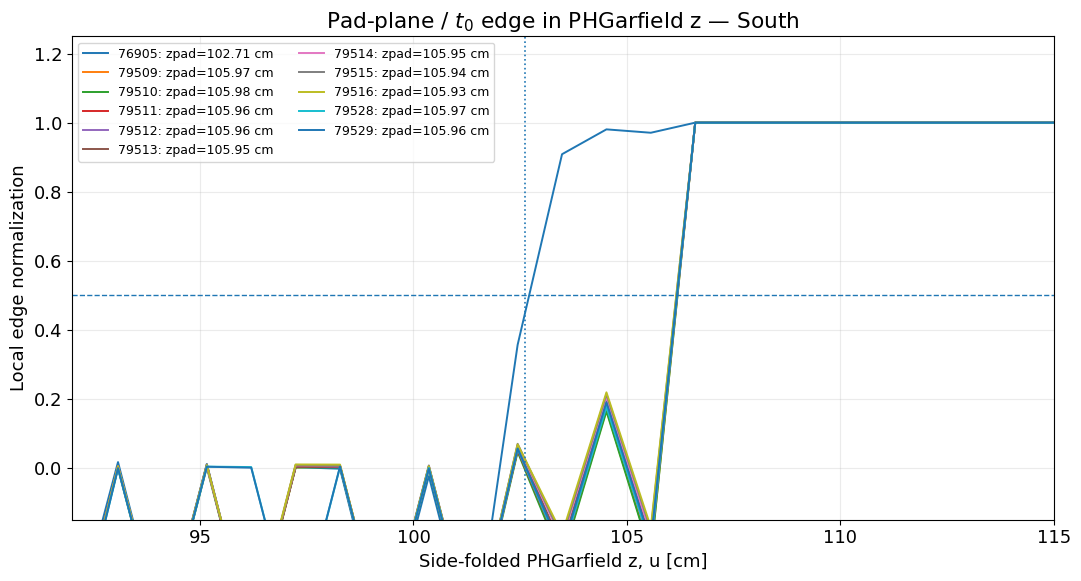

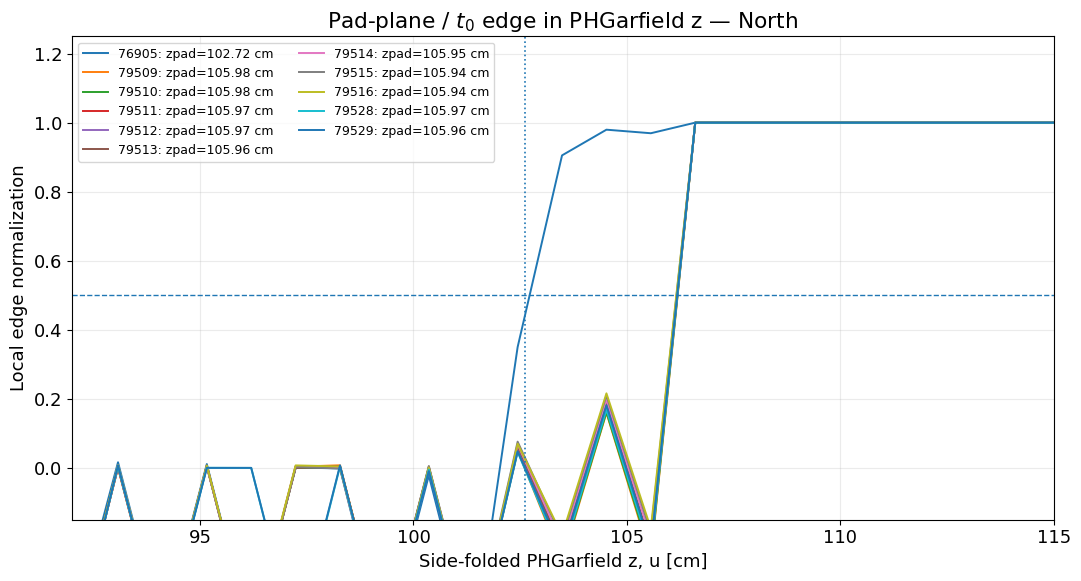

In [16]:

# ============================================================
# 10. PHGarfield-z pad-plane / t0 edge
# ============================================================

Z_PAD_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue

        d = Z_FOLDED[run][side]
        u = d["u"]
        y = d["raw"]

        m = edge_metrics(
            u, y,
            Z_PAD_LEFT_LEVEL,
            Z_PAD_RIGHT_LEVEL,
            Z_PAD_SEARCH,
            expected=Z_PAD_EXPECTED,
        )
        Z_PAD_RESULTS[(run, side)] = m

        yn = normalize_between_levels(y, m["left_level"], m["right_level"])
        ax.plot(u, yn, lw=1.4, label=f"{run}: zpad={m['x50']:.2f} cm")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(Z_PAD_CM, ls=":", lw=1.2)
    ax.set_xlim(*Z_PAD_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"Pad-plane / $t_0$ edge in PHGarfield z — {SIDE_LABEL[side]}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_pad_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_pad_zoom_side{side}.pdf")

    plt.show()


In [17]:

# ============================================================
# 11. Add PHGarfield-z edge residuals to the summary
# ============================================================

z_rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):
        cm = Z_CM_RESULTS.get((run, side))
        pad = Z_PAD_RESULTS.get((run, side))
        if cm is None or pad is None:
            continue

        z_rows.append({
            "run": run,
            "side": side,
            "phg_z_cm_edge_cm": cm["x50"],
            "phg_z_cm_width_10_90_cm": cm["width_10_90"],
            "phg_z_pad_edge_cm": pad["x50"],
            "phg_z_pad_residual_cm": pad["x50"] - Z_PAD_CM,
        })

Z_SUMMARY = pd.DataFrame(z_rows)
SUMMARY_FULL = SUMMARY.merge(Z_SUMMARY, on=["run", "side"], how="left")

display(SUMMARY_FULL)

SUMMARY_FULL.to_csv(OUTPUT_DIR / "drift_t0_z_summary.csv", index=False)
print("saved:", OUTPUT_DIR / "drift_t0_z_summary.csv")


,run,system,side,side_name,t0_bin_50,t0_width_10_90_bins,cm_bin_50,cm_width_10_90_bins,drift_bins,drift_time_ns,vdrift_data_cm_us,phg_z_cm_edge_cm,phg_z_cm_width_10_90_cm,phg_z_pad_edge_cm,phg_z_pad_residual_cm
0,76905,Au+Au,0,South,8.670098,2.733876,250.520815,3.543550,241.850717,13737.120734,7.469178,0.269692,3.171936,102.710250,0.105250
1,76905,Au+Au,1,North,8.648595,2.734163,250.643224,3.108366,241.994629,13745.294916,7.464736,0.288745,2.233550,102.720952,0.115952
2,79509,p+p,0,South,8.389627,2.785865,250.942977,3.852117,242.553350,13777.030284,7.447541,0.390547,1.547431,105.974926,3.369926
3,79509,p+p,1,North,8.517120,2.561883,251.395358,3.881336,242.878238,13795.483944,7.437579,0.308433,0.377856,105.981123,3.376123
4,79510,p+p,0,South,8.418637,2.636628,250.824619,6.107344,242.405982,13768.659797,7.452069,0.254487,0.351873,105.977921,3.372921
5,79510,p+p,1,North,8.572814,2.447461,251.204808,3.200840,242.631994,13781.497258,7.445127,-1.334331,1.880303,105.979629,3.374629
6,79511,p+p,0,South,8.280657,2.755373,250.971720,10.485294,242.691063,13784.852376,7.443315,0.249500,0.395651,105.964909,3.359909
7,79511,p+p,1,North,8.384021,2.542517,251.429425,10.996634,243.045404,13804.978921,7.432463,-1.319439,1.835665,105.968301,3.363301
8,79512,p+p,0,South,8.426613,2.696697,250.935686,4.253930,242.509072,13774.515307,7.448901,-1.305496,0.075442,105.963834,3.358834
9,79512,p+p,1,North,8.620433,2.874914,251.417493,6.650210,242.797060,13790.873010,7.440066,0.279856,0.428023,105.968459,3.363459


saved: plots_drift_t0/drift_t0_z_summary.csv



## Module-by-module QA

The 2D histograms have:

- x axis = `module = 3*sector + radial_region`, 36 modules per side;
- y axis = raw time bin or PHGarfield \(z\);
- bin content = summed cleaned ADC.

The next cells extract \(t_0\), CM time, data drift velocity, and CM-\(z\) edge separately for every module.


In [18]:

# ============================================================
# 12. Module-level extraction helper
# ============================================================

def module_edge_table(run, side):
    rows = []

    if run not in DATA:
        return pd.DataFrame()

    if side not in DATA[run]["time_module"] or side not in DATA[run]["z_module"]:
        return pd.DataFrame()

    modules, t, time2d, labels = DATA[run]["time_module"][side]
    zmods, z, z2d, zlabels = DATA[run]["z_module"][side]

    sign = +1.0 if side == 1 else -1.0
    u = sign * z
    z_order = np.argsort(u)
    u = u[z_order]
    z2d_fold = z2d[z_order, :]

    # Same z rebinning used for the integrated profile.
    u, z2d_fold = rebin_2d_y_sum(u, z2d_fold, Z_REBIN_FACTOR)

    for imod in range(time2d.shape[1]):
        yt = time2d[:, imod]
        yz = z2d_fold[:, imod]

        t0 = edge_metrics(
            t, yt, T0_LEFT_LEVEL, T0_RIGHT_LEVEL, T0_SEARCH, expected=T0_EXPECTED
        )
        cm = edge_metrics(
            t, yt, CM_LEFT_LEVEL, CM_RIGHT_LEVEL, CM_SEARCH, expected=CM_EXPECTED
        )
        zcm = edge_metrics(
            u, yz, Z_CM_LEFT_LEVEL, Z_CM_RIGHT_LEVEL, Z_CM_SEARCH, expected=0.0
        )

        dt_bins = cm["x50"] - t0["x50"]
        dt_ns = dt_bins * TPC_TIME_BIN_NS
        v = Z_PAD_CM / dt_ns * 1000.0 if np.isfinite(dt_ns) and dt_ns > 0 else np.nan

        rows.append({
            "run": run,
            "side": side,
            "module": imod,
            "label": labels[imod] if imod < len(labels) else str(imod),
            "t0_bin": t0["x50"],
            "cm_bin": cm["x50"],
            "vdrift_cm_us": v,
            "z_cm_edge_cm": zcm["x50"],
        })

    return pd.DataFrame(rows)


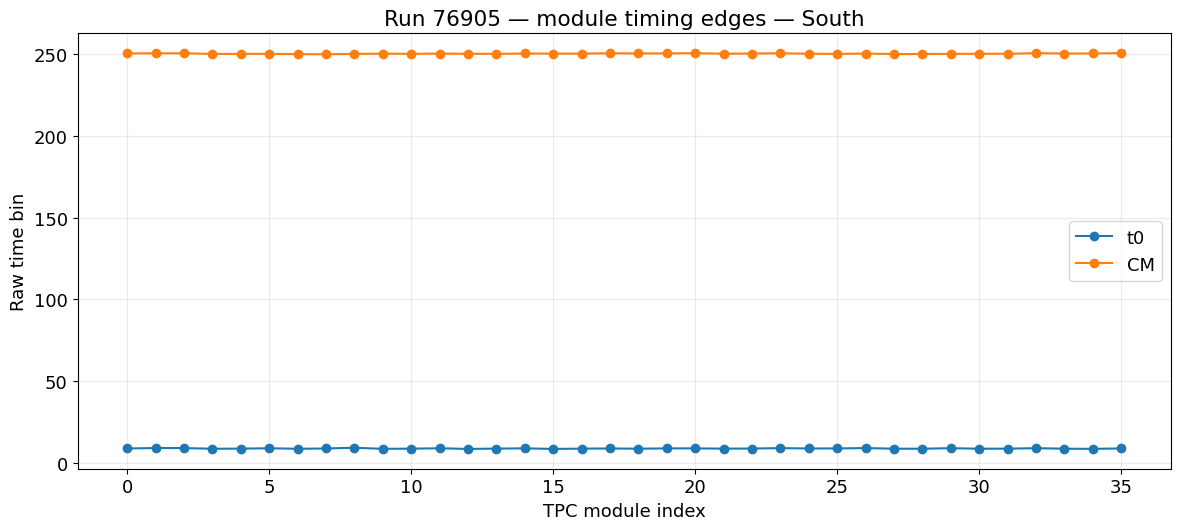

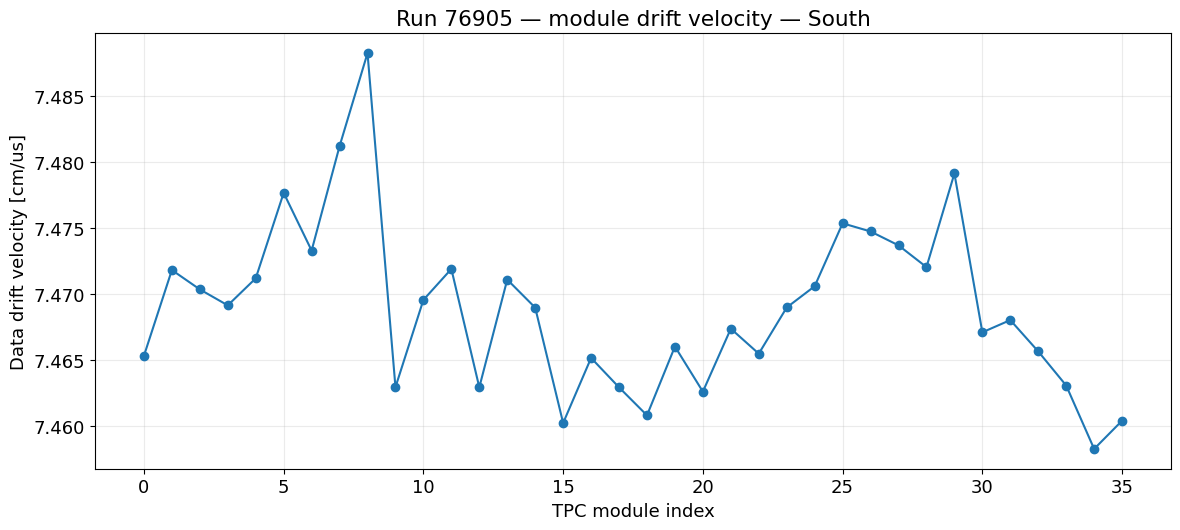

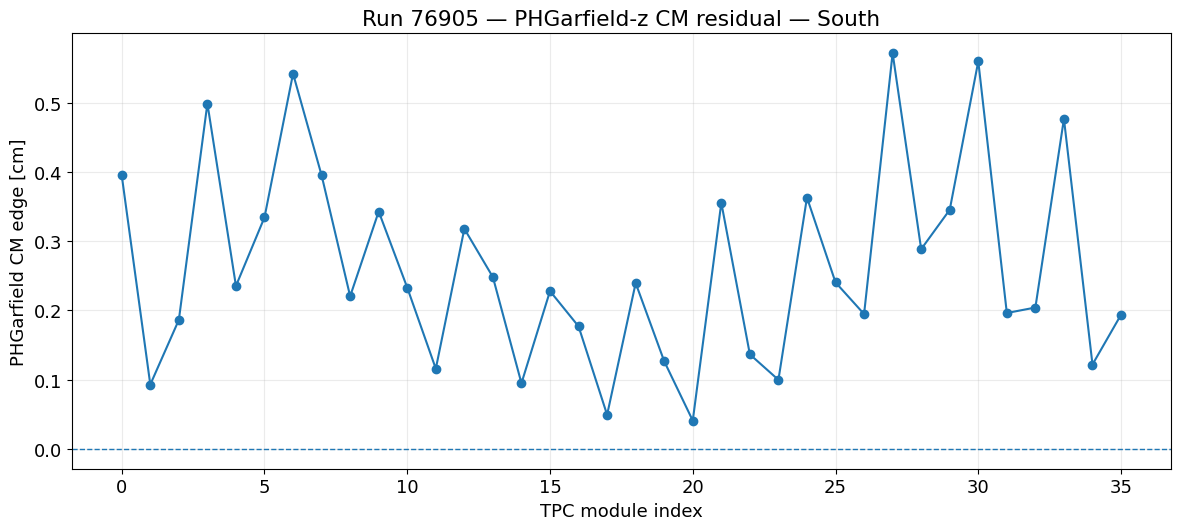

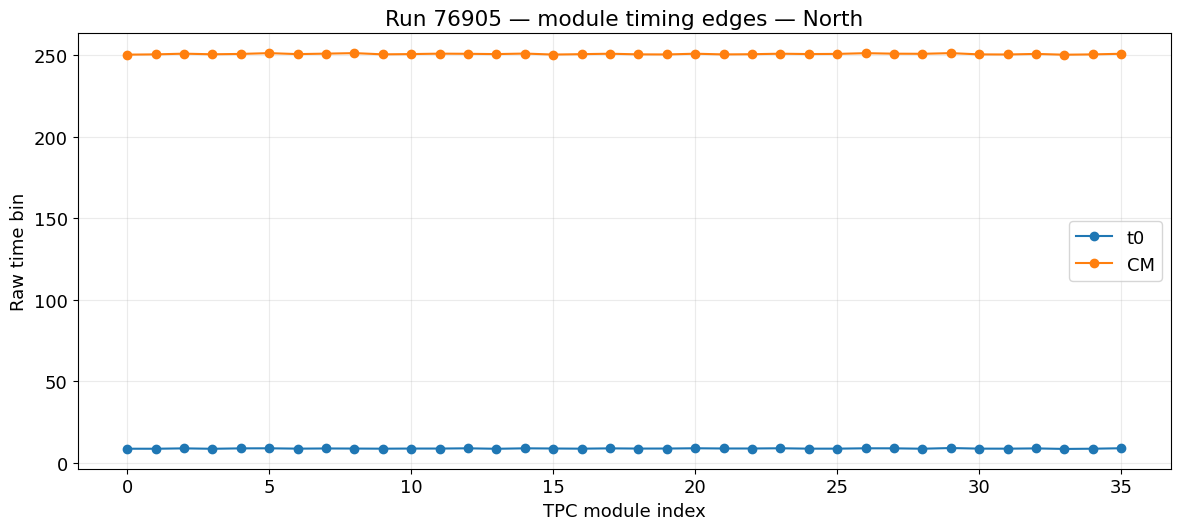

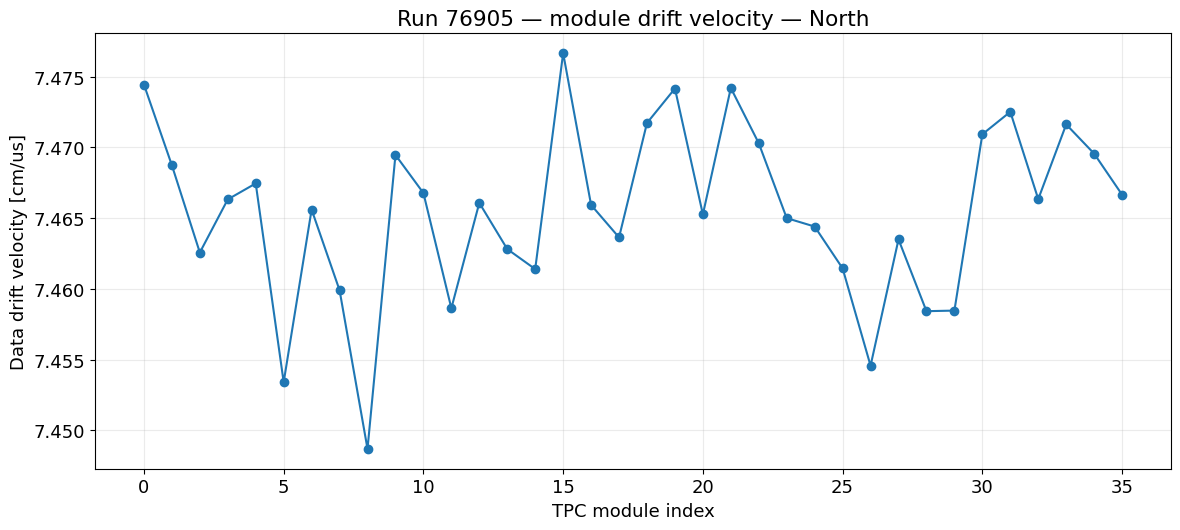

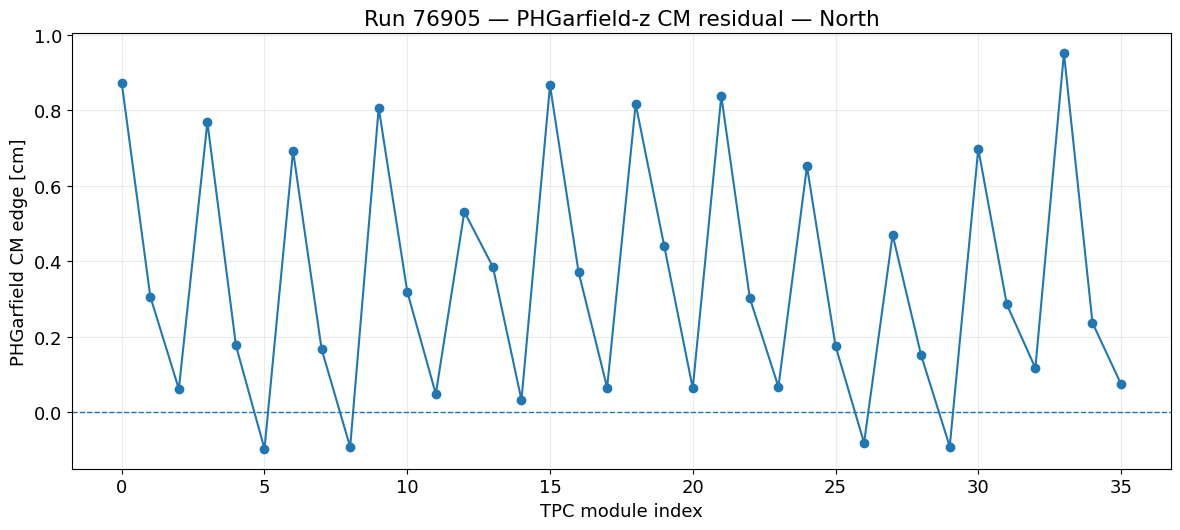

In [19]:

# ============================================================
# 13. Choose one run and inspect module-to-module calibration
# ============================================================

MODULE_RUN = AVAILABLE_RUNS[0]   # edit as needed

for side in (0, 1):
    dfm = module_edge_table(MODULE_RUN, side)
    if dfm.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.plot(dfm["module"], dfm["t0_bin"], "o-", label="t0")
    ax.plot(dfm["module"], dfm["cm_bin"], "o-", label="CM")
    ax.set_xlabel("TPC module index")
    ax.set_ylabel("Raw time bin")
    ax.set_title(f"Run {MODULE_RUN} — module timing edges — {SIDE_LABEL[side]}")
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"modules_time_edges_run{MODULE_RUN}_side{side}.png", dpi=160)
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.plot(dfm["module"], dfm["vdrift_cm_us"], "o-")
    ax.set_xlabel("TPC module index")
    ax.set_ylabel("Data drift velocity [cm/us]")
    ax.set_title(f"Run {MODULE_RUN} — module drift velocity — {SIDE_LABEL[side]}")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"modules_vdrift_run{MODULE_RUN}_side{side}.png", dpi=160)
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.axhline(0.0, ls="--", lw=1)
    ax.plot(dfm["module"], dfm["z_cm_edge_cm"], "o-")
    ax.set_xlabel("TPC module index")
    ax.set_ylabel("PHGarfield CM edge [cm]")
    ax.set_title(f"Run {MODULE_RUN} — PHGarfield-z CM residual — {SIDE_LABEL[side]}")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"modules_zcm_run{MODULE_RUN}_side{side}.png", dpi=160)
    plt.show()


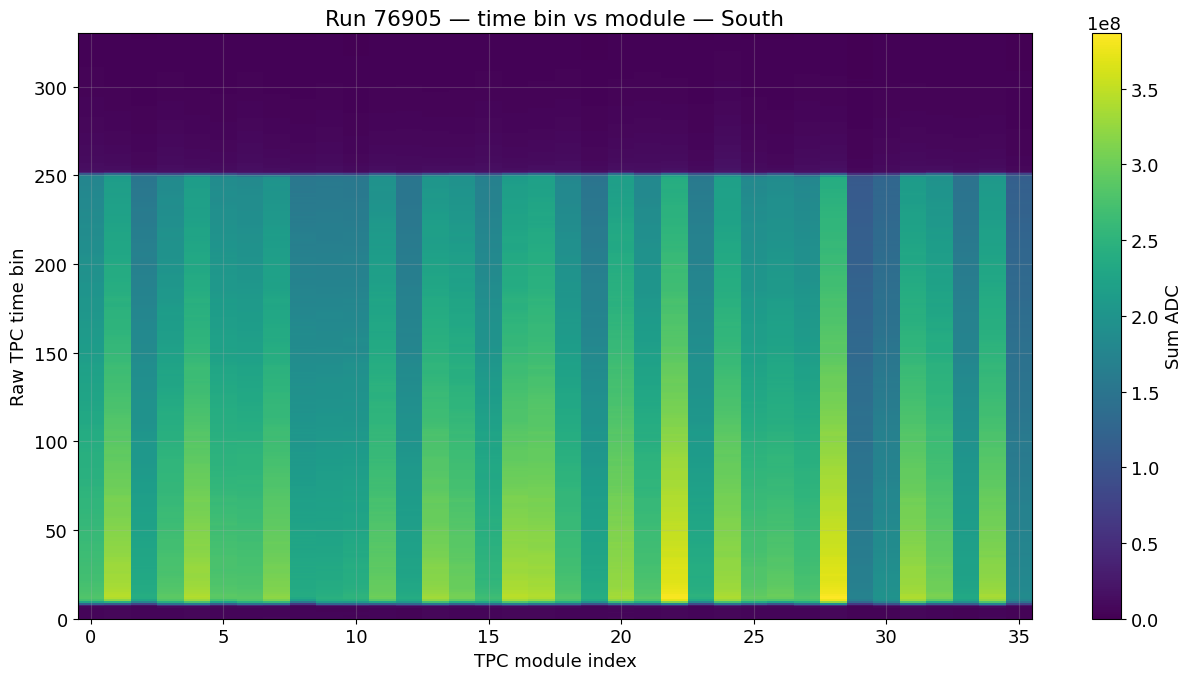

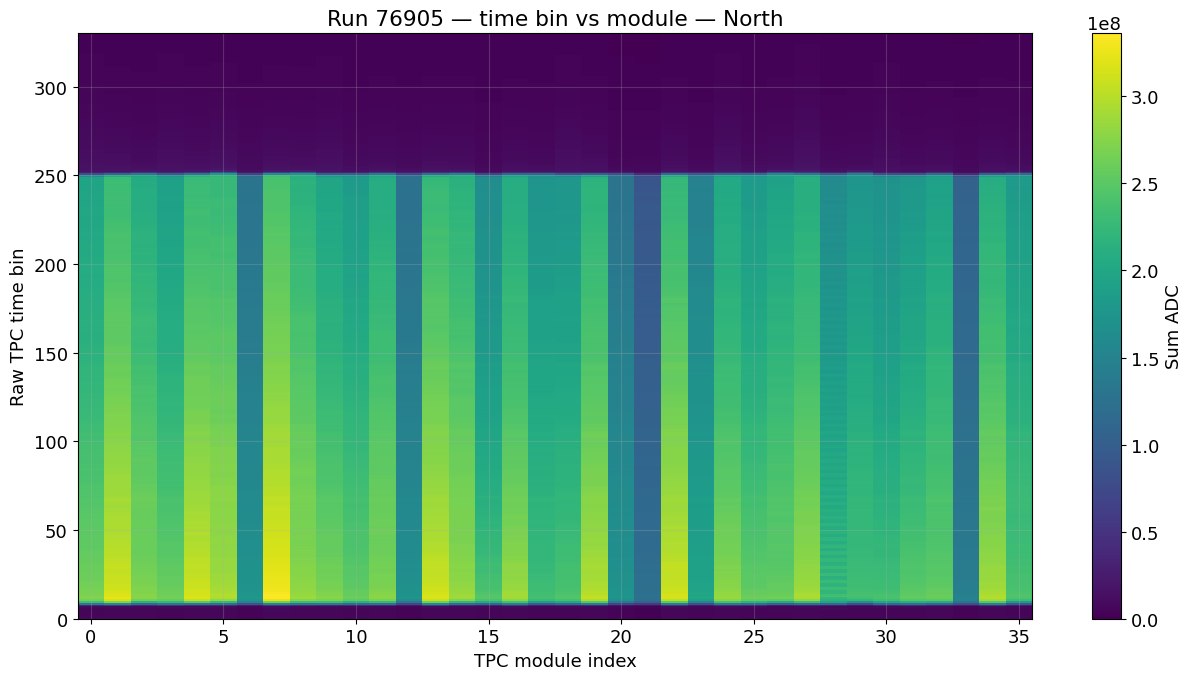

In [20]:

# ============================================================
# 14. Optional: show the actual 2D time-bin vs module QA
# ============================================================

HEATMAP_RUN = MODULE_RUN

for side in (0, 1):
    if side not in DATA[HEATMAP_RUN]["time_module"]:
        continue

    modules, t, values, labels = DATA[HEATMAP_RUN]["time_module"][side]

    fig, ax = plt.subplots(figsize=(13, 7))
    pcm = ax.pcolormesh(
        np.arange(values.shape[1] + 1) - 0.5,
        np.arange(values.shape[0] + 1),
        values,
        shading="auto",
    )
    fig.colorbar(pcm, ax=ax, label="Sum ADC")

    ax.set_ylim(0, 330)
    ax.set_xlabel("TPC module index")
    ax.set_ylabel("Raw TPC time bin")
    ax.set_title(f"Run {HEATMAP_RUN} — time bin vs module — {SIDE_LABEL[side]}")
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_vs_module_run{HEATMAP_RUN}_side{side}.png", dpi=160)

    plt.show()



## First checks

1. **p+p background fit:** it should follow only the smooth out-of-drift component after the CM edge. If it follows physical structure, tighten `TIME_BG_WINDOWS`.
2. **\(t_0\):** compare the 50% rising-edge position between runs and South/North. The nominal PHGarfield reference is bin 8; the data value is measured independently.
3. **CM time:** compare the falling edge around \(\sim260\).
4. **Data drift velocity:** always use \(t_{\rm CM}-t_0\), not the absolute CM time.
5. **PHGarfield \(z\):** the CM edge should approach \(u=0\) when the run-dependent \(P/T\)-corrected drift mapping describes the data.
6. **Modules:** abnormal module \(t_0\), CM time, or \(z_{\rm CM}\) values can be isolated before forming the final calibration.

All numerical windows are intentionally centralized in the top configuration cell.
